# Notebook 02 — Cascade and Simulation

**Purpose:** Define the ten-parameter cascade of spatial migration feasibility, quantify its uncertainty through an unconditional variance decomposition, and compute conditional Monte Carlo commitment depths that condition on observed per-hour grid states. Produces the headline simulation results cited in NE manuscript Section 2 and Section 5.

**Inputs** (from notebook 01):
- `outputs/contracts/stress_correlation_results.json`
- `outputs/contracts/per_hour_destination_availability.parquet`
- `outputs/contracts/workload_parameters.json`

**Outputs** (consumed by notebook 03):
- `outputs/contracts/cascade_parameters.json`
- `outputs/contracts/conditional_mc_results.json`
- `outputs/tables/sensitivity_surface.csv`
- `outputs/tables/sensitivity_tornado.csv`

---

## Notebook Architecture

| Part | Section | Contents |
|---|---|---|
| **0** | Setup | Imports, REPO_ROOT, contract loading, sanity checks |
| **1** | Cascade Framework (Section 2) | 10-parameter definitions, ranges, static product, commitment depth |
| **2** | Unconditional Variance Decomposition (Section 2, Methods) | MC over all parameters, η² attribution, scenario summary |
| **3** | Conditional Monte Carlo (Section 5) | Single facility, empirical fleet, per-GW sweep |
| **4** | Sensitivity Analysis (Section 5, Methods) | 2D surface, tornado |
| **5** | Contract Exports | JSONs + sensitivity CSVs |

## Headline Results (reconciled parameter set)

| Claim | Value | Cell |
|---|---|---|
| Cascade central product | ~0.0384 | 1-3 |
| Commitment depth (cascade baseline) | ~20.4% | 1-4 |
| Variance shares D2/D4/D5/S2 | 44/28/13/13% (verify) | 2-1 |
| Single-facility MC commitment depth | TBD from regression | 3-2 |
| Empirical fleet MC commitment depth | TBD from regression | 3-3 |
| Per-GW sweep @ 10 GW | TBD from regression | 3-4 |

### 0.1 Imports, Paths, Configuration

Standard imports plus the REPO_ROOT resolver (kept in sync with notebook 01 Cell 2-1) so paths work whether the notebook launches from the repo root or from `notebooks/`. Derives `CONTRACTS_DIR`, `FIGURES_DIR`, `TABLES_DIR` from REPO_ROOT and creates them if missing.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 0-1: IMPORTS, PATH RESOLUTION, CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# ─── REPO_ROOT resolver ──────────────────────────────────────────────────────
# Kept in sync with notebooks/01_empirical_evidence.ipynb Cell 2-1. Resolves
# the repo root whether the notebook is launched from the repo root (VS Code,
# Jupyter started at repo root) or from notebooks/ (nbconvert default, or
# Jupyter started inside notebooks/).
# ─────────────────────────────────────────────────────────────────────────────
_cwd = Path.cwd()
if (_cwd / "notebooks").exists() and (_cwd / "data").exists():
    REPO_ROOT = _cwd                      # launched from repo root
elif _cwd.name == "notebooks":
    REPO_ROOT = _cwd.parent               # launched from notebooks/
else:
    REPO_ROOT = _cwd                      # fallback

# Guard against silent mis-resolution: if REPO_ROOT doesn't look like the repo,
# fail loudly here rather than further downstream with a confusing path error.
assert (REPO_ROOT / "notebooks").exists() and (REPO_ROOT / "outputs").exists(), (
    f"REPO_ROOT resolved to {REPO_ROOT}, which does not look like the repo root "
    f"(missing notebooks/ or outputs/). Launch Jupyter from the repo root or "
    f"from notebooks/."
)

# ─── Derived paths ───────────────────────────────────────────────────────────
CONTRACTS_DIR = REPO_ROOT / "outputs" / "contracts"
FIGURES_DIR   = REPO_ROOT / "outputs" / "figures"
TABLES_DIR    = REPO_ROOT / "outputs" / "tables"

CONTRACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)

print(f"REPO_ROOT:     {REPO_ROOT}")
print(f"CONTRACTS_DIR: {CONTRACTS_DIR}")

REPO_ROOT:     C:\Users\dunla\repos\data-center-flexibility-resource-adequacy
CONTRACTS_DIR: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\contracts


### 0.2 Load Contracts from Notebook 01

Reads the three JSON/parquet contracts notebook 01 writes to `outputs/contracts/`: the stress correlation results (source-zone and per-zone aggregates), the per-hour destination availability parquet (realized D1 values by hour), and the workload parameters (S3 central value plus its justification).

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 0-2: LOAD CONTRACTS FROM NOTEBOOK 01
# ══════════════════════════════════════════════════════════════════════════════

with open(CONTRACTS_DIR / "stress_correlation_results.json") as f:
    stress_results = json.load(f)

per_hour_avail = pd.read_parquet(CONTRACTS_DIR / "per_hour_destination_availability.parquet")

with open(CONTRACTS_DIR / "workload_parameters.json") as f:
    workload = json.load(f)

# S3 flows through from workload contract — single source of truth for S3=0.90
# across the cascade. Notebook 01 writes it; notebook 02 reads it; notebook 03
# consumes it via the cascade_parameters.json export written in Cell 5-1 below.
S3_FROM_CONTRACT = workload["s3_parameterization"]

print(f"stress_results top-level keys: {list(stress_results.keys())}")
print(f"per_hour_avail: {per_hour_avail.shape} ({len(per_hour_avail.columns)} cols)")
print(f"workload: S3 = {S3_FROM_CONTRACT}")

stress_results top-level keys: ['metadata', 'headline', 'empirical_destination_lmps', 'per_zone', 'yearly']
per_hour_avail: (200, 19) (19 cols)
workload: S3 = {'value': 0.9, 'justification': 'P99 drain times across two independent datasets range from 4.5 to 12.1 seconds at 60 tok/s, approximately two orders of magnitude below PJM 10-minute dispatch window. S3 = 0.90 reserves 10% of load for long-running or batched requests.', 'pjm_dispatch_window_seconds': 600}


### 0.3 Contract Sanity Checks

Asserts that the contracts have the expected shape, fields, and values before any downstream cell depends on them. Specifically verifies the parquet row count and destination column count are in expected ranges, the `pjm_co_stressed_mw` column is populated (Cell 4-2 fix verification), and the workload contract's S3 value is 0.90.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 0-3: CONTRACT SANITY CHECKS
# ══════════════════════════════════════════════════════════════════════════════
# Fail loudly if upstream contracts are malformed, stale, or missing expected
# fields. These checks guard against silent drift between notebook 01 outputs
# and notebook 02 inputs.
# ══════════════════════════════════════════════════════════════════════════════

# ─── Parquet structural checks ───────────────────────────────────────────────
assert 150 <= per_hour_avail.shape[0] <= 250, f"Unexpected row count: {per_hour_avail.shape[0]}"
assert "timestamp" in per_hour_avail.columns, "timestamp column missing"
assert "pjm_co_stressed_mw" in per_hour_avail.columns, "pjm_co_stressed_mw column missing"
dest_cols = [c for c in per_hour_avail.columns if c not in ("timestamp", "pjm_co_stressed_mw")]
assert 15 <= len(dest_cols) <= 25, f"Unexpected destination count: {len(dest_cols)}"

# ─── Cell 4-2 fix verification ───────────────────────────────────────────────
# Pre-fix, notebook 01 filtered dest_zones by 'PJM' string, which never matched
# (all dest zones are cross-BA: CAISO/ERCOT/MISO/NYISO), leaving pjm_co_stressed_mw
# all zeros. Post-fix should have ~30 non-zero hours averaging several GW.
n_nonzero = int((per_hour_avail["pjm_co_stressed_mw"] > 0).sum())
assert n_nonzero > 0, "pjm_co_stressed_mw is all zeros — Cell 4-2 fix did not persist"
assert n_nonzero >= 20, f"Only {n_nonzero} non-zero PJM co-stress hours; expected at least 20"

# ─── Workload contract ───────────────────────────────────────────────────────
# S3 is stored as a nested dict in workload_parameters.json: the numeric value
# travels with its justification and the PJM dispatch window reference. Unpack
# the scalar here so the rest of the notebook has a single S3_VALUE to use.
assert isinstance(S3_FROM_CONTRACT, dict), (
    f"Expected s3_parameterization to be a dict, got {type(S3_FROM_CONTRACT).__name__}"
)
assert "value" in S3_FROM_CONTRACT, "s3_parameterization missing 'value' field"
S3_VALUE = float(S3_FROM_CONTRACT["value"])
assert S3_VALUE == 0.90, f"S3 value = {S3_VALUE}, expected 0.90"

# ─── Summary ─────────────────────────────────────────────────────────────────
pjm_mean = per_hour_avail.loc[per_hour_avail["pjm_co_stressed_mw"] > 0, "pjm_co_stressed_mw"].mean()
print(f"✓ Contract sanity checks passed")
print(f"  Stress hours:                   {len(per_hour_avail)}")
print(f"  Destination zones (cross-BA):   {len(dest_cols)}")
print(f"  PJM co-stress non-zero hours:   {n_nonzero} / {len(per_hour_avail)}")
print(f"  PJM co-stress mean (non-zero):  {pjm_mean:,.0f} MW")
print(f"  S3 (from workload contract):    {S3_VALUE}")

✓ Contract sanity checks passed
  Stress hours:                   200
  Destination zones (cross-BA):   17
  PJM co-stress non-zero hours:   160 / 200
  PJM co-stress mean (non-zero):  8,541 MW
  S3 (from workload contract):    0.9


## Part 1: Cascade Framework (Section 2)

- **1-1** Ten-parameter definitions, ranges, and `FLEX_FRAC`
- **1-2** Static cascade product (conservative / central / optimistic)
- **1-3** Commitment depth formula

Decomposes spatial migration feasibility into ten multiplicative parameters: three source-side (S1, S2, S3), five destination-side (D1–D5), and two execution (E1, E2). The **effective spatial fraction** is the product of all ten, representing the share of facility load that can be shifted off the source node during a capacity market dispatch event. The **commitment depth** adds Colangelo et al. flexibility on the shiftable-compute residual within the S1 envelope (Colangelo et al. 2026, corrected formula applied to the S1 envelope rather than 1 − spatial).

Parameter values and ranges reconciled against NE manuscript Methods. S3 central flows from `workload_parameters.json` (notebook 01 output) rather than being hardcoded, so any future reparameterization of S3 based on updated drain-time data propagates automatically through the cascade.

### 1.1 Ten-Parameter Definitions and Ranges

Defines all ten cascade parameters (S1, S2, S3, D1–D5, E1, E2) as scalars plus the `CASCADE_RANGES` dict that gives each parameter a (conservative, central, optimistic) tuple. Reconciled against NE manuscript Methods: S2 central = 0.70, E1 = 0.95, E2 = 0.98. Asserts that scalar values and range centrals agree — single source of truth for all downstream cells. Also defines `FLEX_FRAC = 0.25` (Colangelo).

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 1-1: TEN-PARAMETER CASCADE DEFINITIONS AND RANGES
# ══════════════════════════════════════════════════════════════════════════════
# Effective Spatial Fraction = S1 × S2 × S3 × D1 × D2 × D3 × D4 × D5 × E1 × E2
#
# Each parameter is an independent filter on the spatial migration pathway.
# Grounding tags indicate source quality:
#   DATA                : empirically grounded
#   STRUCTURAL          : definitional (e.g. inference share by design)
#   ESTIMATED-MODERATE  : published literature with disagreement
#   ESTIMATED-WEAK      : no direct measurement; regulatory/modeling judgment
#
# Reconciled values per NE manuscript Methods. See notebook 02 README for the
# reconciliation history (v18 scalars were updated in place but ranges drifted;
# this cell is the single clean source of truth).
# ══════════════════════════════════════════════════════════════════════════════

# ─── Source-side ─────────────────────────────────────────────────────────────
CASCADE_S1 = 0.70           # [STRUCTURAL] Workload candidacy (inference-dominant scenario).
                            #   Fixed at 0.70 within the inference-dominant framing; not sampled.

CASCADE_S2 = 0.70           # [ESTIMATED-WEAK] Data locality.
                            #   Central = 0.70 reflects a conservative "regulatory floor" framing
                            #   anchored on data residency requirements for cross-region inference
                            #   routing (same-country, same-jurisdiction). Range [0.60, 0.95]
                            #   accommodates stricter or looser residency regimes. No published
                            #   shiftability measurement exists; this is the primary modeling
                            #   vulnerability flagged in Section 2.

CASCADE_S3 = S3_VALUE       # [DATA] Operational feasibility given advance notice.
                            #   Sourced from outputs/contracts/workload_parameters.json (notebook 01).
                            #   Central 0.90 reserves 10% of load for long-running or batched
                            #   requests whose drain time exceeds the PJM 10-minute dispatch window.
                            #   Grounded in DynamoLLM and BurstGPT P99 drain-time analysis
                            #   (see workload contract justification).

# ─── Destination-side ────────────────────────────────────────────────────────
CASCADE_D1 = 0.99           # [DATA] Destination availability.
                            #   Pillar 2 empirical: 198/200 ComEd stress hours had cross-BA
                            #   destinations available (99.0%). See notebook 01 Part 1.

CASCADE_D2 = 0.33           # [ESTIMATED-WEAK] Utilization headroom = 1 - util.
                            #   Central util ~0.67 per SemiAnalysis/MIT GPU measurements.
                            #   Range [0.20, 0.50] reflects GPU utilization 50-80%.
                            #   Highest variance contribution (~44%) per Methods variance
                            #   decomposition; addressed directly in Part 4 sensitivity surface.

CASCADE_D3 = 0.88           # [ESTIMATED-MODERATE] Hardware compatibility (CUDA backward compat,
                            #   TensorRT). compatible_fraction_reference Layer 1: 0.80-0.92.
                            #   Excludes pre-staging, which is now D5.

CASCADE_D4 = 0.50           # [ESTIMATED-MODERATE] Inference workload share at destination.
                            #   compatible_fraction_reference Layer 2: 0.33-0.67.
                            #   Deloitte (Nov 2025): ~50% in 2025; McKinsey: 30-40% by 2030.

CASCADE_D5 = 0.65           # [ESTIMATED-WEAK] Operational readiness / pre-staging.
                            #   compatible_fraction_reference Layer 3: 0.50-0.80.
                            #   Weakest layer per Pillar 1 TGV. Hyperscaler own-fleet 0.60-0.80;
                            #   merchant floor 0.50. Central = 0.65 from reference central scenario.

# ─── Execution ───────────────────────────────────────────────────────────────
CASCADE_E1 = 0.95           # [ESTIMATED] Routing completion.
                            #   Conservative SLA envelope below measured cloud load-balancer
                            #   failure rates (~0.999 steady-state), to accommodate DNS propagation,
                            #   health-check latency, and cross-BA routing variability not captured
                            #   in published SLAs. Range widened from Bartlett v18's tight (0.995,
                            #   0.999) to reflect uncertainty in conservative framing. Variance
                            #   contribution <5% per Methods; result is numerically insensitive.

CASCADE_E2 = 0.98           # [ESTIMATED] Bandwidth adequacy.
                            #   Conservative SLA envelope below hyperscaler WAN headroom implied
                            #   by the orders-of-magnitude argument in Methods §E2. Deliberate
                            #   buffer for unmodeled congestion events. Variance contribution
                            #   <5% per Methods; result is numerically insensitive.

# ─── Colangelo flexibility floor ──────────────────────────────────────────────────
FLEX_FRAC = 0.25            # [DATA] Aggregate software-orchestrated flexibility on
                            #   shiftable-compute residual within the S1 envelope.
                            #   Consistent with the 25% combined power reduction sustained
                            #   for 3 hours on a 256-GPU Phoenix cluster by Colangelo et al.
                            #   (Nat Energy 11:254, 2026) via combined control knobs (DVFS,
                            #   pausing, GPU reallocation) — not DVFS-specific. Adopted as
                            #   a conservative ceiling for what software orchestration can
                            #   deliver on compute-amenable load..

# ─── Parameter ranges (conservative, central, optimistic) ────────────────────
# Single source of truth for all downstream sensitivity and variance-decomp work.
# CENTRAL column must equal the scalar values above — enforced by assertion below.
CASCADE_RANGES = {
    'S1': (0.70,  0.70,  0.70),     # Fixed within inference-dominant scenario
    'S2': (0.60,  0.70,  0.95),     # Reconciled: central moved 0.80→0.70, endpoints unchanged
    'S3': (0.85,  0.90,  0.95),     # Matches workload-contract central; endpoints unchanged
    'D1': (0.945, 0.99,  0.995),    # Empirical-forward range for climate/reflexivity
    'D2': (0.20,  0.33,  0.50),     # Narrowed per Methods: GPU util 50-80% → headroom 0.20-0.50
    'D3': (0.80,  0.88,  0.92),     # HW compat Layer 1 (excludes pre-staging)
    'D4': (0.33,  0.50,  0.67),     # Inference share Layer 2
    'D5': (0.50,  0.65,  0.80),     # Pre-staging Layer 3
    'E1': (0.90,  0.95,  0.99),     # Reconciled: widened to contain new central 0.95
    'E2': (0.95,  0.98,  0.995),    # Reconciled: widened to contain new central 0.98
}

# ─── Consistency check: scalars must match range centrals ────────────────────
_scalars = {
    'S1': CASCADE_S1, 'S2': CASCADE_S2, 'S3': CASCADE_S3,
    'D1': CASCADE_D1, 'D2': CASCADE_D2, 'D3': CASCADE_D3,
    'D4': CASCADE_D4, 'D5': CASCADE_D5,
    'E1': CASCADE_E1, 'E2': CASCADE_E2,
}
for _k, _v in _scalars.items():
    _central = CASCADE_RANGES[_k][1]
    assert abs(_v - _central) < 1e-9, (
        f"{_k} scalar ({_v}) differs from CASCADE_RANGES central ({_central}). "
        f"Fix one or the other — they must agree."
    )

print("TEN-PARAMETER CASCADE — central values")
print("─" * 60)
print(f"  Source:       S1={CASCADE_S1:.2f}  S2={CASCADE_S2:.2f}  S3={CASCADE_S3:.2f}")
print(f"  Destination:  D1={CASCADE_D1:.3f} D2={CASCADE_D2:.2f}  D3={CASCADE_D3:.2f}")
print(f"                D4={CASCADE_D4:.2f}  D5={CASCADE_D5:.2f}")
print(f"  Execution:    E1={CASCADE_E1:.2f}  E2={CASCADE_E2:.2f}")
print(f"  Flex:         FLEX_FRAC={FLEX_FRAC:.2f}")
print(f"✓ Scalar/range consistency check passed")

TEN-PARAMETER CASCADE — central values
────────────────────────────────────────────────────────────
  Source:       S1=0.70  S2=0.70  S3=0.90
  Destination:  D1=0.990 D2=0.33  D3=0.88
                D4=0.50  D5=0.65
  Execution:    E1=0.95  E2=0.98
  DVFS:         FLEX_FRAC=0.25
✓ Scalar/range consistency check passed


### 1.2 Static Cascade Product

Computes the ten-parameter cascade product at the conservative, central, and optimistic range endpoints. The central value is the headline number cited in §2 (target: 0.0384). Regression asserts against the reconciled Bartlett v18 target.

The parameter definitions and ranges above are the single source of truth for every downstream cascade computation in this notebook. The next two cells compute **point estimates** at the range endpoints (Cell 1-2) and the **Colangelo-corrected commitment depth** at the central point (Cell 1-3). The full uncertainty propagation — unconditional Monte Carlo and variance attribution — lives in Part 2.

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 1-2: STATIC CASCADE PRODUCT (conservative / central / optimistic)
# ══════════════════════════════════════════════════════════════════════════════
# Point estimates at the three range endpoints, computed from CASCADE_RANGES.
# The central value is the headline number cited in §2 and Methods.
# ══════════════════════════════════════════════════════════════════════════════

def _cascade_product(vals):
    """Product of all ten cascade parameters given a {name: value} dict."""
    return (vals['S1'] * vals['S2'] * vals['S3'] *
            vals['D1'] * vals['D2'] * vals['D3'] *
            vals['D4'] * vals['D5'] *
            vals['E1'] * vals['E2'])

_con_vals     = {k: v[0] for k, v in CASCADE_RANGES.items()}
_central_vals = {k: v[1] for k, v in CASCADE_RANGES.items()}
_opt_vals     = {k: v[2] for k, v in CASCADE_RANGES.items()}

CASCADE_CONSERVATIVE   = _cascade_product(_con_vals)
EFFECTIVE_SPATIAL_FRAC = _cascade_product(_central_vals)
CASCADE_OPTIMISTIC     = _cascade_product(_opt_vals)

print("CASCADE PRODUCT")
print("─" * 60)
print(f"  Conservative:  {CASCADE_CONSERVATIVE:.4f}")
print(f"  Central:       {EFFECTIVE_SPATIAL_FRAC:.4f}")
print(f"  Optimistic:    {CASCADE_OPTIMISTIC:.4f}")

# ─── Regression check against reconciled Bartlett v18 target ─────────────────
assert abs(EFFECTIVE_SPATIAL_FRAC - 0.0384) < 0.001, (
    f"Central cascade product {EFFECTIVE_SPATIAL_FRAC:.4f} does not match "
    f"reconciled Bartlett v18 target 0.0384. Investigate parameter drift."
)
print(f"✓ Regression check: central product matches reconciled Bartlett v18 (0.0384)")

CASCADE PRODUCT
────────────────────────────────────────────────────────────
  Conservative:  0.0076
  Central:       0.0384
  Optimistic:    0.1527
✓ Regression check: central product matches reconciled Bartlett v18 (0.0384)


### 1.3 Commitment Depth Formula

Applies the Colangelo-corrected commitment depth formula `depth = spatial + FLEX_FRAC × (S1 - spatial)` — Colangelo flex operates on the shiftable-compute residual *within the S1 envelope*, not on `(1 - spatial)`. Produces the baseline commitment depth (target: 20.4%), the Flex-only floor (17.5%, no spatial migration), and the endpoint sensitivities.

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 1-3: COMMITMENT DEPTH (Colangelo-corrected formula)
# ══════════════════════════════════════════════════════════════════════════════
# Commitment depth = spatial_fraction + FLEX_FRAC × (S1 - spatial_fraction)
#
# The flexibility multiplier applies to the shiftable-compute residual WITHIN the
# S1 envelope, not to (1 - spatial). Colangelo et al. (2026) measured their 25%
# power reduction at the GPU cluster level, not the facility meter; neither
# DVFS nor pausing nor resource reallocation can reduce cooling or infrastructure
# load. Applying flexibility to (1 - spatial) would include non-compute facility 
# load (cooling, power conditioning) in the DVFS base, overstating the flexibility 
# floor.
#
# The Flex-only floor (no spatial migration at all) is FLEX_FRAC × S1 = 17.5%.
# This is the minimum commitment depth achievable through compute flexibility
# alone, without any cross-BA migration.
# ══════════════════════════════════════════════════════════════════════════════

COMMITMENT_DEPTH_BASELINE = (
    EFFECTIVE_SPATIAL_FRAC + FLEX_FRAC * (CASCADE_S1 - EFFECTIVE_SPATIAL_FRAC)
)

FLEX_ONLY_FLOOR = FLEX_FRAC * CASCADE_S1  # 0.25 × 0.70 = 17.5%

# Also compute commitment depth at conservative and optimistic endpoints
_depth_con = CASCADE_CONSERVATIVE + FLEX_FRAC * (CASCADE_S1 - CASCADE_CONSERVATIVE)
_depth_opt = CASCADE_OPTIMISTIC   + FLEX_FRAC * (CASCADE_S1 - CASCADE_OPTIMISTIC)

print("COMMITMENT DEPTH")
print("─" * 60)
print(f"  Flex-only floor:       {FLEX_ONLY_FLOOR:>6.1%}  (no spatial migration)")
print(f"  Conservative cascade:  {_depth_con:>6.1%}  (spatial {CASCADE_CONSERVATIVE:.4f} + Flex residual)")
print(f"  Central cascade:       {COMMITMENT_DEPTH_BASELINE:>6.1%}  (spatial {EFFECTIVE_SPATIAL_FRAC:.4f} + Flex residual)")
print(f"  Optimistic cascade:    {_depth_opt:>6.1%}  (spatial {CASCADE_OPTIMISTIC:.4f} + Flex residual)")

# ─── Regression check against reconciled Bartlett v18 target ─────────────────
assert abs(COMMITMENT_DEPTH_BASELINE - 0.204) < 0.002, (
    f"Central commitment depth {COMMITMENT_DEPTH_BASELINE:.4f} does not match "
    f"reconciled Bartlett v18 target 0.204 (20.4%). Investigate."
)
print(f"✓ Regression check: central commitment depth matches reconciled target (20.4%)")

COMMITMENT DEPTH
────────────────────────────────────────────────────────────
  DVFS-only floor:        17.5%  (no spatial migration)
  Conservative cascade:   18.1%  (spatial 0.0076 + DVFS residual)
  Central cascade:        20.4%  (spatial 0.0384 + DVFS residual)
  Optimistic cascade:     29.0%  (spatial 0.1527 + DVFS residual)
✓ Regression check: central commitment depth matches reconciled target (20.4%)


## Part 2: Unconditional Variance Decomposition (§2, Methods)

- **2-1** Monte Carlo over all ten cascade parameters (N=50,000), variance attribution via η² correlation ratios
- **2-2** Scenario summary table (conservative / central / optimistic) and one-at-a-time parameter sensitivity

Propagates parameter uncertainty through the cascade product **without** conditioning on empirical grid state — D1 is sampled from its prior range rather than read from the per-hour parquet. This produces the variance shares cited in Methods as evidence that D2, D4, D5, and S2 are the dominant uncertainty drivers and therefore the empirical investment priorities for tightening the cascade estimate. The conditional (empirical) Monte Carlo in Part 3 is the complement: it reads the real per-hour destination availability from notebook 01's stress correlation contract and computes commitment depth at the actually-observed grid states.

S1 is held fixed at 0.70 (scenario-defining scalar, not drawn); all nine other parameters are sampled independently. D1 uses a triangular distribution peaked at the empirical central value (0.99); all other sampled parameters use uniform distributions over their `CASCADE_RANGES` endpoints.

### 2.1 Cascade Monte Carlo and Variance Decomposition

Runs N=50,000 Monte Carlo draws over the nine stochastic cascade parameters (S1 held fixed). D1 uses a triangular distribution peaked at the empirical central; all other drawn parameters are uniform over their `CASCADE_RANGES` endpoints. Computes η² correlation ratios via 20-bin quantile binning to attribute output variance to each parameter, then compares computed shares against the paper-cited values (D2=44, D4=28, D5=13, S2=13).

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 2-1: CASCADE MONTE CARLO + VARIANCE DECOMPOSITION
# ══════════════════════════════════════════════════════════════════════════════
# Monte Carlo sensitivity analysis for the ten-parameter cascade.
# Produces:
#   1. Distribution of cascade product and commitment depth
#   2. Variance attribution (η² correlation ratios) identifying which
#      parameters drive cascade uncertainty under independent sampling
#
# Sampling:
#   S1: held fixed (scenario-definer, not drawn)
#   D1: triangular(con, central, opt) — concentrates mass at empirical anchor
#   All others: uniform(con, opt) over CASCADE_RANGES endpoints
#
# Variance attribution is computed on the cascade product. Because commitment
# depth is an affine function of the product at fixed S1
# (commit = product + FLEX_FRAC × (S1 - product)), the variance SHARES are
# identical whether computed on product or commitment.
#
# INPUTS:  CASCADE_S1, CASCADE_RANGES, FLEX_FRAC (from Part 1)
# OUTPUTS: CASCADE_MC_PRODUCTS, CASCADE_MC_COMMITMENT, CASCADE_ETA_SQ
# ══════════════════════════════════════════════════════════════════════════════

np.random.seed(429)
N = 50_000

S1_FIXED = CASCADE_S1  # held fixed; not sampled

# ─── Draw samples from CASCADE_RANGES (single source of truth) ───────────────
# All parameters except S1 and D1 use uniform(con, opt).
# D1 uses triangular peaked at central to reflect its empirical grounding.
_sampled_params = ['S2', 'S3', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2']

samples = {}
for _p in _sampled_params:
    _con, _central, _opt = CASCADE_RANGES[_p]
    if _p == 'D1':
        samples[_p] = np.random.triangular(_con, _central, _opt, N)
    else:
        samples[_p] = np.random.uniform(_con, _opt, N)

# ─── Cascade product and commitment depth for each draw ──────────────────────
CASCADE_MC_PRODUCTS = (
    S1_FIXED *
    samples['S2'] * samples['S3'] *
    samples['D1'] * samples['D2'] * samples['D3'] *
    samples['D4'] * samples['D5'] *
    samples['E1'] * samples['E2']
)

CASCADE_MC_COMMITMENT = (
    CASCADE_MC_PRODUCTS + FLEX_FRAC * (S1_FIXED - CASCADE_MC_PRODUCTS)
)

# ─── Summary distribution ────────────────────────────────────────────────────
_p = CASCADE_MC_PRODUCTS
_c = CASCADE_MC_COMMITMENT

print(f"CASCADE MONTE CARLO (N={N:,}, 9 sampled parameters + S1 fixed)")
print("=" * 74)
print(f"  Cascade product:   mean={np.mean(_p):.4f}  std={np.std(_p):.4f}  "
      f"[P5={np.percentile(_p,5):.4f}, P95={np.percentile(_p,95):.4f}]")
print(f"  Commitment depth:  mean={np.mean(_c):.1%}  std={np.std(_c):.4f}  "
      f"[P5={np.percentile(_c,5):.1%}, P95={np.percentile(_c,95):.1%}]")

# ─── Variance attribution (η² correlation ratios) ────────────────────────────
# For each sampled parameter:
#   1. Digitize into 20 quantile bins
#   2. Compute between-group variance of the cascade product across bins
#   3. Divide by total variance of the cascade product
# Result is the fraction of product variance explained by that parameter alone,
# approximating the first-order Sobol index.
# ─────────────────────────────────────────────────────────────────────────────

_total_var = np.var(CASCADE_MC_PRODUCTS)
_mean_p = np.mean(CASCADE_MC_PRODUCTS)
CASCADE_ETA_SQ = {}

for _param, _vals in samples.items():
    _bin_edges = np.percentile(_vals, np.linspace(0, 100, 21))
    _bins = np.digitize(_vals, _bin_edges)
    _group_means = []
    _group_counts = []
    for _b in range(1, 21):
        _mask = (_bins == _b)
        _n_b = int(_mask.sum())
        if _n_b > 0:
            _group_means.append(CASCADE_MC_PRODUCTS[_mask].mean())
            _group_counts.append(_n_b)
    _group_means = np.array(_group_means)
    _group_counts = np.array(_group_counts)
    _between_var = np.sum(_group_counts * (_group_means - _mean_p)**2) / N
    CASCADE_ETA_SQ[_param] = _between_var / _total_var

# Grounding tags (consistent with Cell 1-1 comments)
_grounding = {
    'S2': 'ESTIMATED-WEAK',
    'S3': 'DATA',
    'D1': 'DATA',
    'D2': 'ESTIMATED-WEAK',
    'D3': 'ESTIMATED-MODERATE',
    'D4': 'ESTIMATED-MODERATE',
    'D5': 'ESTIMATED-WEAK',
    'E1': 'ESTIMATED',
    'E2': 'DATA',
}

_eta_sum = sum(CASCADE_ETA_SQ.values())

print(f"\nVARIANCE ATTRIBUTION (η² correlation ratios)")
print("=" * 74)
print(f"  {'Param':<6} | {'η²':>8} | {'% of Σ η²':>10} | {'Grounding':<20}")
print(f"  {'─' * 68}")
for _param, _eta in sorted(CASCADE_ETA_SQ.items(), key=lambda x: -x[1]):
    _pct = 100 * _eta / _eta_sum
    print(f"  {_param:<6} | {_eta:>8.4f} | {_pct:>9.1f}% | {_grounding[_param]:<20}")
print(f"  {'─' * 68}")
print(f"  Σ η² = {_eta_sum:.4f}  (≈1.0 confirms negligible parameter interactions)")

# ─── Compare against paper Methods cited shares ──────────────────────────────
# Paper §29 cites D2=44%, D4=28%, D5=13%, and S2≈13% (§40).
# If reconciled E1/E2 ranges move these meaningfully, the paper needs updating.
print(f"\nPAPER METHODS COMPARISON")
print("=" * 74)
_paper_shares = {'D2': 0.44, 'D4': 0.28, 'D5': 0.13, 'S2': 0.13}
print(f"  {'Param':<6} | {'Paper cite':>10} | {'Computed':>10} | {'Δ (pp)':>8}")
print(f"  {'─' * 44}")
for _param, _paper_pct in _paper_shares.items():
    _computed_pct = CASCADE_ETA_SQ[_param] / _eta_sum
    _delta_pp = 100 * (_computed_pct - _paper_pct)
    _flag = "  ← check" if abs(_delta_pp) > 2.0 else ""
    print(f"  {_param:<6} | {_paper_pct:>9.1%} | {_computed_pct:>9.1%} | {_delta_pp:>+6.1f}pp{_flag}")

CASCADE MONTE CARLO (N=50,000, 9 sampled parameters + S1 fixed)
  Cascade product:   mean=0.0429  std=0.0163  [P5=0.0208, P95=0.0734]
  Commitment depth:  mean=20.7%  std=0.0122  [P5=19.1%, P95=23.0%]

VARIANCE ATTRIBUTION (η² correlation ratios)
  Param  |       η² |  % of Σ η² | Grounding           
  ────────────────────────────────────────────────────────────────────
  D2     |   0.4205 |      43.9% | ESTIMATED-WEAK      
  D4     |   0.2668 |      27.9% | ESTIMATED-MODERATE  
  D5     |   0.1238 |      12.9% | ESTIMATED-WEAK      
  S2     |   0.1197 |      12.5% | ESTIMATED-WEAK      
  D3     |   0.0096 |       1.0% | ESTIMATED-MODERATE  
  S3     |   0.0083 |       0.9% | DATA                
  E1     |   0.0052 |       0.5% | ESTIMATED           
  E2     |   0.0017 |       0.2% | DATA                
  D1     |   0.0012 |       0.1% | DATA                
  ────────────────────────────────────────────────────────────────────
  Σ η² = 0.9569  (≈1.0 confirms negligible paramete

### 2.2 Scenario Summary and One-at-a-Time Sensitivity

Two complementary views of parameter uncertainty. First, a scenario summary table showing cascade product, commitment depth, and firm share at the three `CASCADE_RANGES` endpoints (joint worst/best corners, not probabilistic bounds). Second, a one-at-a-time tornado: for each parameter, sweep it low→high while holding the other nine at central, record the marginal impact on commitment depth, sort descending.

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 2-2: SCENARIO SUMMARY AND ONE-AT-A-TIME SENSITIVITY
# ══════════════════════════════════════════════════════════════════════════════
# Two complementary views of parameter uncertainty:
#
# 1. SCENARIO SUMMARY — point estimates at the three range corners
#    (all parameters simultaneously at conservative / central / optimistic).
#    These are JOINT WORST/BEST CASE bounds, not probabilistic bounds. The
#    meaningful uncertainty envelope is the MC P5/P95 from Cell 2-1.
#
# 2. ONE-AT-A-TIME SENSITIVITY — marginal impact of each parameter, sweeping
#    low → high while holding all others at their central values. Complements
#    Cell 2-1's joint variance decomposition: variance shares answer
#    "which parameter drives uncertainty when everything moves?", tornado
#    answers "which parameter moves the output most when held in isolation?"
# ══════════════════════════════════════════════════════════════════════════════

# ─── Scenario summary table ──────────────────────────────────────────────────
_central_depth = (
    EFFECTIVE_SPATIAL_FRAC + FLEX_FRAC * (CASCADE_S1 - EFFECTIVE_SPATIAL_FRAC)
)
_con_depth = (
    CASCADE_CONSERVATIVE + FLEX_FRAC * (CASCADE_S1 - CASCADE_CONSERVATIVE)
)
_opt_depth = (
    CASCADE_OPTIMISTIC + FLEX_FRAC * (CASCADE_S1 - CASCADE_OPTIMISTIC)
)

CASCADE_SCENARIOS = {
    'Conservative': {'cascade': CASCADE_CONSERVATIVE, 'depth': _con_depth},
    'Central':      {'cascade': EFFECTIVE_SPATIAL_FRAC, 'depth': _central_depth},
    'Optimistic':   {'cascade': CASCADE_OPTIMISTIC,    'depth': _opt_depth},
}

print("CASCADE SCENARIO SUMMARY")
print("=" * 74)
print(f"  {'Scenario':<14} | {'Cascade':>9} | {'Depth':>7} | {'Firm':>6}")
print(f"  {'':14} | {'Product':>9} | {'':>7} | {'Share':>6}")
print(f"  {'─' * 44}")
for _label, _s in CASCADE_SCENARIOS.items():
    _firm = 1 - _s['depth']
    print(f"  {_label:<14} | {_s['cascade']:>9.4f} | {_s['depth']:>6.1%} | {_firm:>5.1%}")
print(f"  {'─' * 44}")
print(f"  {'Flex-only floor':<14} | {'—':>9} | {FLEX_ONLY_FLOOR:>6.1%} | {1-FLEX_ONLY_FLOOR:>5.1%}")
print("\n  Note: conservative/optimistic are JOINT WORST/BEST corner estimates,")
print("  not probabilistic bounds. Use Cell 2-1 MC P5/P95 for uncertainty envelope.")

# ─── Monte Carlo uncertainty envelope (from Cell 2-1) ────────────────────────
print(f"\n  MC-derived uncertainty envelope (N={N:,}, P5–P95):")
print(f"    Cascade product:   "
      f"[{np.percentile(CASCADE_MC_PRODUCTS,5):.4f}, "
      f"{np.percentile(CASCADE_MC_PRODUCTS,95):.4f}]")
print(f"    Commitment depth:  "
      f"[{np.percentile(CASCADE_MC_COMMITMENT,5):.1%}, "
      f"{np.percentile(CASCADE_MC_COMMITMENT,95):.1%}]")

# ─── One-at-a-time parameter sensitivity ─────────────────────────────────────
# Hold nine parameters at central, sweep the tenth low→high, record the
# cascade product and commitment depth at each endpoint. Sorted descending
# by absolute impact on commitment depth (tornado ordering).
# ─────────────────────────────────────────────────────────────────────────────

_central_vals = {k: v[1] for k, v in CASCADE_RANGES.items()}

def _cascade_from_dict(d):
    return (d['S1'] * d['S2'] * d['S3'] *
            d['D1'] * d['D2'] * d['D3'] *
            d['D4'] * d['D5'] *
            d['E1'] * d['E2'])

def _commit_from_cascade(c):
    return c + FLEX_FRAC * (CASCADE_S1 - c)

_oat_rows = []
for _param in CASCADE_RANGES.keys():
    if _param == 'S1':
        continue  # S1 is fixed; no sweep
    _con, _central, _opt = CASCADE_RANGES[_param]

    _vals_lo = dict(_central_vals); _vals_lo[_param] = _con
    _vals_hi = dict(_central_vals); _vals_hi[_param] = _opt

    _casc_lo = _cascade_from_dict(_vals_lo)
    _casc_hi = _cascade_from_dict(_vals_hi)
    _depth_lo = _commit_from_cascade(_casc_lo)
    _depth_hi = _commit_from_cascade(_casc_hi)

    _oat_rows.append({
        'param': _param,
        'lo': _con, 'hi': _opt,
        'depth_lo': _depth_lo, 'depth_hi': _depth_hi,
        'abs_impact_pp': 100 * abs(_depth_hi - _depth_lo),
    })

_oat_rows.sort(key=lambda r: -r['abs_impact_pp'])

print(f"\nONE-AT-A-TIME PARAMETER SENSITIVITY (sorted by |Δ depth|)")
print("=" * 74)
print(f"  {'Param':<6} | {'Lo':>6} | {'Hi':>6} | {'Depth Lo':>9} | "
      f"{'Depth Hi':>9} | {'|Δ|':>7}")
print(f"  {'─' * 62}")
for _r in _oat_rows:
    print(f"  {_r['param']:<6} | {_r['lo']:>6.3f} | {_r['hi']:>6.3f} | "
          f"{_r['depth_lo']:>8.1%} | {_r['depth_hi']:>8.1%} | "
          f"{_r['abs_impact_pp']:>5.1f}pp")

CASCADE SCENARIO SUMMARY
  Scenario       |   Cascade |   Depth |   Firm
                 |   Product |         |  Share
  ────────────────────────────────────────────
  Conservative   |    0.0076 |  18.1% | 81.9%
  Central        |    0.0384 |  20.4% | 79.6%
  Optimistic     |    0.1527 |  29.0% | 71.0%
  ────────────────────────────────────────────
  DVFS-only floor |         — |  17.5% | 82.5%

  Note: conservative/optimistic are JOINT WORST/BEST corner estimates,
  not probabilistic bounds. Use Cell 2-1 MC P5/P95 for uncertainty envelope.

  MC-derived uncertainty envelope (N=50,000, P5–P95):
    Cascade product:   [0.0208, 0.0734]
    Commitment depth:  [19.1%, 23.0%]

ONE-AT-A-TIME PARAMETER SENSITIVITY (sorted by |Δ depth|)
  Param  |     Lo |     Hi |  Depth Lo |  Depth Hi |     |Δ|
  ──────────────────────────────────────────────────────────────
  D2     |  0.200 |  0.500 |    19.2% |    21.9% |   2.6pp
  D4     |  0.330 |  0.670 |    19.4% |    21.4% |   2.0pp
  S2     |  0.6

## Part 3: Conditional Monte Carlo (§5)

- **3-1** Setup: MC configuration, parameter scheme, destination infrastructure from parquet contract
- **3-2** Single facility (500 MW): conditional commitment depth distribution, CVaR, reliability curve
- **3-3** Empirical fleet (geographically distributed, variable per-hour size from PJM co-stress)
- **3-4** Per-GW parametric fleet sweep (0.5 GW to 15 GW), contention onset identification
- **3-5** Four-panel conditional MC figure

Replaces the parametric prior on D1 with the per-hour empirical realization from `outputs/contracts/per_hour_destination_availability.parquet` — this is what makes the Monte Carlo **conditional**. For each stress hour, the simulation observes which destination zones are unstressed and uses their realized capacities, then draws D2/D4/D5 independently from their uniform priors to sample the residual destination-side absorption uncertainty an operator faces at commitment time.

**Parameter scheme** (see §5 discussion for rationale): six parameters are held fixed at their reconciled central values because from an operator's perspective at commitment time they are either scope-defining (S1), software properties the operator knows in-house (S3, D3), regulatory facts (S2), or high-confidence vendor SLAs (E1, E2). Three parameters are drawn each MC iteration because they represent the residual absorption uncertainty the operator cannot observe at commit time: D2 (destination GPU utilization headroom), D4 (destination inference workload share), D5 (destination pre-staging readiness). D1 is observed per-hour from the parquet, not drawn.

This is methodologically distinct from Part 2. Part 2 decomposes **scientific parameter uncertainty** in the cascade (variance shares answer "where should empirical work focus?"). Part 3 models **operator decision uncertainty** at commitment time (CVaR and reliability curves answer "what MW can an operator firmly commit at a given confidence level?"). The two analyses answer different questions using overlapping parameter sets.

### 3.1 Setup and Destination Infrastructure

Configures the conditional MC: fixes S1/S2/S3/D3/E1/E2 at reconciled centrals, draws D2/D4/D5 from uniform priors, observes D1 per-hour from the parquet. Rebuilds `hour_dest_available_mw` (list of dicts, one per stress hour, mapping unstressed zones to their MW) and `hour_pjm_co_stressed_mw` (aggregate per-hour PJM co-stress, for the empirical fleet). These two structures are the clean replacement for Cross_BA v5's in-memory `stress_df`/`meta` dependency.

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 3-1: CONDITIONAL MC SETUP AND DESTINATION INFRASTRUCTURE
# ══════════════════════════════════════════════════════════════════════════════
# Configures the conditional Monte Carlo parameter scheme and rebuilds the
# per-hour destination availability structures from the parquet contract
# written by notebook 01 (replaces Cross_BA v5's in-memory stress_df/meta).
#
# PARAMETER SCHEME (see Part 3 header markdown for rationale):
#   Fixed:    S1, S2, S3, D3, E1, E2   (scope, known-by-operator, or fixed SLA)
#   Observed: D1                        (per-hour from parquet — the "conditional")
#   Drawn:    D2, D4, D5                (residual destination absorption uncertainty)
#
# INPUTS:  per_hour_avail (from Cell 0-2), CASCADE_* (from Cell 1-1), FLEX_FRAC
# OUTPUTS: hour_dest_available_mw (list[dict]),
#          hour_pjm_co_stressed_mw (list[float]),
#          n_stress_hours (int), CONDITIONAL_MC_CONFIG (dict)
# ══════════════════════════════════════════════════════════════════════════════

np.random.seed(42)  # Matches Cross_BA v5 conditional MC baseline

N_DRAWS = 2000  # MC draws per stress hour (200 × 2000 = 400,000 total)

# ─── Fixed parameters (held constant across all draws and hours) ────────────
# All values pulled from Cell 1-1 — single source of truth. The fixed set
# represents what an operator knows at commitment time.
S1_FIXED  = CASCADE_S1   # 0.70  — scenario-defining workload candidacy
S2_FIXED  = CASCADE_S2   # 0.70  — regulatory data-locality regime
S3_FIXED  = CASCADE_S3   # 0.90  — software drain-time property, from workload contract
D3_FIXED  = CASCADE_D3   # 0.88  — hardware compatibility (engineering fact)
E1_FIXED  = CASCADE_E1   # 0.95  — routing completion SLA envelope
E2_FIXED  = CASCADE_E2   # 0.98  — bandwidth SLA envelope

# Source-side product (facility-relative): the fraction of facility load that
# WANTS to migrate in a given stress hour. Same for every hour and draw.
SOURCE_SIDE_FRAC = S1_FIXED * S2_FIXED * S3_FIXED

# Destination absorption multiplier (per-draw, applied to raw available MW):
# effective_headroom = raw_avail × D2 × D3 × D4 × D5
# D3 is fixed; D2/D4/D5 are drawn per iteration.
# E1 × E2 apply to the feasible migrated MW at the end (execution losses).

# ─── Drawn parameters (one vector of N_DRAWS per parameter, reused per hour) ─
# Drawing once and reusing keeps the per-hour distributions strictly comparable:
# hour-to-hour variation reflects grid state only, not different random draws.
_D2_lo, _D2_central, _D2_hi = CASCADE_RANGES['D2']
_D4_lo, _D4_central, _D4_hi = CASCADE_RANGES['D4']
_D5_lo, _D5_central, _D5_hi = CASCADE_RANGES['D5']

D2_DRAWS = np.random.uniform(_D2_lo, _D2_hi, size=N_DRAWS)
D4_DRAWS = np.random.uniform(_D4_lo, _D4_hi, size=N_DRAWS)
D5_DRAWS = np.random.uniform(_D5_lo, _D5_hi, size=N_DRAWS)

# ─── Rebuild hour_dest_available_mw from parquet ─────────────────────────────
# Cross_BA v5 built this from stress_df (in-memory pandas structure). Notebook
# 02 reads it from the precomputed parquet contract. The semantics are identical:
# for each stress hour, a dict of {zone: MW} for unstressed destination zones.
#
# A "zone is available" iff its parquet column value for that hour is > 0.
# (Notebook 01 zeros out a zone's MW when that zone is co-stressed.)

_dest_cols = [c for c in per_hour_avail.columns
              if c not in ('timestamp', 'pjm_co_stressed_mw')]

hour_dest_available_mw = []
for _, _row in per_hour_avail.iterrows():
    _avail = {_z: float(_row[_z]) for _z in _dest_cols if _row[_z] > 0}
    hour_dest_available_mw.append(_avail)

# Per-hour PJM co-stress (aggregate MW across co-stressed PJM zones)
hour_pjm_co_stressed_mw = per_hour_avail['pjm_co_stressed_mw'].astype(float).tolist()

n_stress_hours = len(per_hour_avail)

# ─── Diagnostic print ────────────────────────────────────────────────────────
_avail_mw_per_hour = np.array([sum(h.values()) for h in hour_dest_available_mw])
_pjm_mw_per_hour = np.array(hour_pjm_co_stressed_mw)

print("CONDITIONAL MONTE CARLO — Setup and Destination Infrastructure")
print("=" * 74)
print(f"  Source zone:                 PJM_COMED")
print(f"  Stress hours:                {n_stress_hours}")
print(f"  Cross-RTO destination zones: {len(_dest_cols)}")
print(f"  MC draws per stress hour:    {N_DRAWS:,}")
print(f"  Total MC samples:            {n_stress_hours * N_DRAWS:,}")
print()
print(f"  Fixed parameter set:")
print(f"    S1={S1_FIXED:.2f}  S2={S2_FIXED:.2f}  S3={S3_FIXED:.2f}  "
      f"D3={D3_FIXED:.2f}  E1={E1_FIXED:.2f}  E2={E2_FIXED:.2f}")
print(f"    → source-side fraction (S1×S2×S3) = {SOURCE_SIDE_FRAC:.4f}")
print()
print(f"  Drawn parameter ranges:")
print(f"    D2 ~ Uniform[{_D2_lo:.2f}, {_D2_hi:.2f}]  (util headroom)")
print(f"    D4 ~ Uniform[{_D4_lo:.2f}, {_D4_hi:.2f}]  (inference share)")
print(f"    D5 ~ Uniform[{_D5_lo:.2f}, {_D5_hi:.2f}]  (pre-staging)")
print()
print(f"  Per-hour destination availability (across {n_stress_hours} stress hours):")
print(f"    Min available MW:  {_avail_mw_per_hour.min():>10,.0f}")
print(f"    Mean available MW: {_avail_mw_per_hour.mean():>10,.0f}")
print(f"    Max available MW:  {_avail_mw_per_hour.max():>10,.0f}")
print()
print(f"  Per-hour PJM co-stress (variable fleet size for empirical fleet MC):")
print(f"    Hours with PJM co-stress > 0:  {(_pjm_mw_per_hour > 0).sum()} / {n_stress_hours}")
print(f"    Mean co-stressed PJM MW (when > 0): "
      f"{_pjm_mw_per_hour[_pjm_mw_per_hour > 0].mean():,.0f}")
print(f"    Max co-stressed PJM MW:  {_pjm_mw_per_hour.max():,.0f}")

CONDITIONAL_MC_CONFIG = {
    'n_draws': N_DRAWS,
    'n_stress_hours': n_stress_hours,
    'source_zone': 'PJM_COMED',
    'fixed': {'S1': S1_FIXED, 'S2': S2_FIXED, 'S3': S3_FIXED,
              'D3': D3_FIXED, 'E1': E1_FIXED, 'E2': E2_FIXED},
    'drawn': {
        'D2': {'distribution': 'uniform', 'low': _D2_lo, 'high': _D2_hi},
        'D4': {'distribution': 'uniform', 'low': _D4_lo, 'high': _D4_hi},
        'D5': {'distribution': 'uniform', 'low': _D5_lo, 'high': _D5_hi},
    },
    'observed': 'D1 (per-hour from parquet)',
}

CONDITIONAL MONTE CARLO — Setup and Destination Infrastructure
  Source zone:                 PJM_COMED
  Stress hours:                200
  Cross-RTO destination zones: 17
  MC draws per stress hour:    2,000
  Total MC samples:            400,000

  Fixed parameter set:
    S1=0.70  S2=0.70  S3=0.90  D3=0.88  E1=0.95  E2=0.98
    → source-side fraction (S1×S2×S3) = 0.4410

  Drawn parameter ranges:
    D2 ~ Uniform[0.20, 0.50]  (util headroom)
    D4 ~ Uniform[0.33, 0.67]  (inference share)
    D5 ~ Uniform[0.50, 0.80]  (pre-staging)

  Per-hour destination availability (across 200 stress hours):
    Min available MW:           0
    Mean available MW:     13,488
    Max available MW:      17,200

  Per-hour PJM co-stress (variable fleet size for empirical fleet MC):
    Hours with PJM co-stress > 0:  160 / 200
    Mean co-stressed PJM MW (when > 0): 8,541
    Max co-stressed PJM MW:  14,464


### 3.2 Single Facility (500 MW)

For each of the 200 ComEd stress hours, draws 2,000 samples of D2/D4/D5 and computes commitment depth for a 500 MW inference-dominant facility conditional on the observed per-hour destination availability. Produces the §5 headline: mean, median, P5/P95, VaR/CVaR at 5%, % constrained, and an operator-facing reliability curve showing committable MW at each confidence level (50%, 75%, 90%, 95%, 99%, 99.5%, 99.9%).

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 3-2: CONDITIONAL MC — SINGLE FACILITY (500 MW)
# ══════════════════════════════════════════════════════════════════════════════
# For each of the 200 stress hours, draws D2/D4/D5 (N_DRAWS times) and computes
# the commitment depth for a 500 MW inference-dominant facility conditional on
# the observed per-hour destination availability.
#
# Commitment depth formula (matches Part 1 cell 1-3 convention):
#   feasible_mig_mw = min(facility_wants_to_migrate, effective_headroom) × E1 × E2
#   spatial_frac    = feasible_mig_mw / facility_mw
#   commit_depth    = spatial_frac + FLEX_FRAC × (S1 - spatial_frac)
#
# OUTPUTS: single_fac_commit_depths (n_stress_hours × N_DRAWS array),
#          SINGLE_FAC_RESULTS dict with mean/median/P5/P95/VaR/CVaR
# ══════════════════════════════════════════════════════════════════════════════

SINGLE_FAC_MW = 500  # §5 reference facility

# What a 500 MW facility "wants to migrate" each hour (source-side × facility MW)
_single_fac_wants = SINGLE_FAC_MW * SOURCE_SIDE_FRAC

# Preallocate result matrix: rows = stress hours, cols = MC draws
single_fac_commit_depths = np.zeros((n_stress_hours, N_DRAWS))
single_fac_headroom_ratios = np.zeros((n_stress_hours, N_DRAWS))

# ─── Main loop: for each stress hour, compute per-draw commitment depth ─────
for _h in range(n_stress_hours):
    _raw_avail_mw = sum(hour_dest_available_mw[_h].values())

    # Vectorized across draws: effective_headroom per draw
    _effective_headroom = _raw_avail_mw * D2_DRAWS * D3_FIXED * D4_DRAWS * D5_DRAWS

    # Feasible migrated MW: capped at what the facility wants to migrate
    _feasible = np.minimum(_single_fac_wants, _effective_headroom) * E1_FIXED * E2_FIXED

    # Spatial fraction and commitment depth
    _spatial_frac = _feasible / SINGLE_FAC_MW
    _commit = _spatial_frac + FLEX_FRAC * (S1_FIXED - _spatial_frac)

    single_fac_commit_depths[_h, :] = _commit
    single_fac_headroom_ratios[_h, :] = (
        _effective_headroom / _single_fac_wants if _single_fac_wants > 0 else np.inf
    )

# ─── Aggregate statistics ────────────────────────────────────────────────────
_flat = single_fac_commit_depths.flatten()

_mean   = _flat.mean()
_median = np.median(_flat)
_p5     = np.percentile(_flat, 5)
_p95    = np.percentile(_flat, 95)
_var5   = _p5  # Value at Risk at 5%
_cvar5  = _flat[_flat <= _var5].mean()  # Conditional Value at Risk below P5

# % of MC samples where the operator was constrained by destination headroom
# (i.e. effective headroom < what the facility wanted to migrate)
_pct_constrained = 100 * (single_fac_headroom_ratios < 1.0).mean()

SINGLE_FAC_RESULTS = {
    'facility_mw':         SINGLE_FAC_MW,
    'migrating_mw':        _single_fac_wants,
    'mean_commit_depth':   _mean,
    'median_commit_depth': _median,
    'p5_commit_depth':     _p5,
    'p95_commit_depth':    _p95,
    'var5':                _var5,
    'cvar5':               _cvar5,
    'pct_constrained':     _pct_constrained,
}

# ─── Summary print ───────────────────────────────────────────────────────────
print(f"CONDITIONAL MC — SINGLE FACILITY ({SINGLE_FAC_MW} MW)")
print("=" * 74)
print(f"  Facility:                {SINGLE_FAC_MW} MW")
print(f"  Wants to migrate each hour: {_single_fac_wants:.1f} MW  "
      f"(= {SINGLE_FAC_MW} × S1 × S2 × S3 = {SOURCE_SIDE_FRAC:.4f})")
print(f"  Total MC samples:        {n_stress_hours * N_DRAWS:,}")
print()
print(f"  Commitment depth distribution:")
print(f"    Mean:                  {_mean:>6.1%}")
print(f"    Median:                {_median:>6.1%}")
print(f"    P5 – P95 range:        [{_p5:.1%}, {_p95:.1%}]")
print()
print(f"  Operator-facing tail metrics:")
print(f"    VaR @ 5%:              {_var5:>6.1%}  ({_var5 * SINGLE_FAC_MW:.1f} MW)")
print(f"    CVaR below P5:         {_cvar5:>6.1%}  ({_cvar5 * SINGLE_FAC_MW:.1f} MW)")
print(f"    Flex-only floor:       {FLEX_ONLY_FLOOR:>6.1%}  ({FLEX_ONLY_FLOOR * SINGLE_FAC_MW:.1f} MW)")
print(f"    % draws constrained:   {_pct_constrained:>6.1f}%  (headroom < wants-to-migrate)")
print()
print(f"  Cascade baseline (from Cell 1-3): {COMMITMENT_DEPTH_BASELINE:.1%}")
print(f"  Conditional MC uplift:            {_mean - COMMITMENT_DEPTH_BASELINE:+.1%}")

# ─── Reliability curve (operator commitment view) ────────────────────────────
print()
print("  RELIABILITY CURVE — what can be firmly committed at each confidence level")
print("  " + "─" * 68)
print(f"  {'Confidence':<14} {'Commit depth':<16} {'Commit MW':<14}")
print("  " + "─" * 68)
for _conf in [50, 75, 90, 95, 99, 99.5, 99.9]:
    _q = 100 - _conf
    _commit_frac = np.percentile(_flat, _q)
    _commit_mw = _commit_frac * SINGLE_FAC_MW
    print(f"  {_conf:>5.1f}%         {_commit_frac:>6.1%}            {_commit_mw:>6.1f} MW")
print("  " + "─" * 68)

# ─── Pre-fix reference (diagnostic, not regression) ──────────────────────────
# v5 baseline (52.0%) used old parameters (S2=0.80, E1=0.997, E2=0.995) AND
# old 19-zone destination pool (included phantom MISO_ILLINOIS 1,647 MW).
# Delta below reflects both parameter reconciliation and zone metadata fixes.
print()
print("  Pre-fix reference (diagnostic, not assertion):")
print(f"    v5 baseline:  52.0% (S2=0.80, E1=0.997, E2=0.995, 19-zone pool)")
print(f"    Current:      {_mean:.1%} (S2={S2_FIXED}, E1={E1_FIXED}, E2={E2_FIXED}, {len(_dest_cols)}-zone pool)")
print(f"    Δ (combined): {_mean - 0.520:+.1%}")

CONDITIONAL MC — SINGLE FACILITY (500 MW)
  Facility:                500 MW
  Wants to migrate each hour: 220.5 MW  (= 500 × S1 × S2 × S3 = 0.4410)
  Total MC samples:        400,000

  Commitment depth distribution:
    Mean:                   46.9%
    Median:                 48.3%
    P5 – P95 range:        [30.7%, 48.3%]

  Operator-facing tail metrics:
    VaR @ 5%:               30.7%  (153.5 MW)
    CVaR below P5:          23.5%  (117.6 MW)
    DVFS-only floor:        17.5%  (87.5 MW)
    % draws constrained:      6.8%  (headroom < wants-to-migrate)

  Cascade baseline (from Cell 1-3): 20.4%
  Conditional MC uplift:            +26.5%

  RELIABILITY CURVE — what can be firmly committed at each confidence level
  ────────────────────────────────────────────────────────────────────
  Confidence     Commit depth     Commit MW     
  ────────────────────────────────────────────────────────────────────
   50.0%          48.3%             241.5 MW
   75.0%          48.3%             24

### 3.3 Empirical Fleet

Same MC draws as Cell 3-2, but the migrating fleet in each hour is the actual PJM co-stress MW (variable fleet size driven by intra-PJM stress correlation) instead of a single fixed facility. This is the capacity-market-relevant framing where multiple PJM facilities bid DR simultaneously and only the co-stressed ones need to migrate. Computes the coordination gap — the spread between population mean (aggregate value) and P5 firm commitment (what any individual operator can bid alone).

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 3-3: CONDITIONAL MC — EMPIRICAL FLEET (geographically distributed)
# ══════════════════════════════════════════════════════════════════════════════
# Same D2/D4/D5 draws as Cell 3-2, but the migrating fleet is the actual per-hour
# PJM co-stress MW (variable fleet size driven by intra-PJM stress correlation)
# rather than a single fixed facility. This is the framing that matches a
# capacity market where multiple PJM facilities bid DR simultaneously and only
# co-stressed ones actually need to migrate in a given event.
#
# OUTPUTS: fleet_commit_depths (n_stress_hours × N_DRAWS),
#          EMPIRICAL_FLEET_RESULTS dict,
#          coordination_gap (headline finding)
# ══════════════════════════════════════════════════════════════════════════════

FLEET_REF_MW = 10_000  # 10 GW reference for MW illustration only

fleet_commit_depths = np.zeros((n_stress_hours, N_DRAWS))
fleet_constrained = np.zeros((n_stress_hours, N_DRAWS), dtype=bool)
fleet_migrating_mw_per_hour = np.zeros(n_stress_hours)

for _h in range(n_stress_hours):
    _co_stressed_mw = hour_pjm_co_stressed_mw[_h]
    _fleet_wants = _co_stressed_mw * SOURCE_SIDE_FRAC
    fleet_migrating_mw_per_hour[_h] = _fleet_wants

    _raw_avail_mw = sum(hour_dest_available_mw[_h].values())
    _effective_headroom = _raw_avail_mw * D2_DRAWS * D3_FIXED * D4_DRAWS * D5_DRAWS

    if _fleet_wants > 0:
        _feasible = np.minimum(_fleet_wants, _effective_headroom) * E1_FIXED * E2_FIXED
        _spatial_frac = _feasible / _co_stressed_mw  # depth relative to co-stressed fleet
    else:
        # No PJM co-stress this hour: spatial_frac undefined relative to zero fleet,
        # but the commitment depth is meaningful.
        _feasible = np.zeros(N_DRAWS)
        _spatial_frac = np.zeros(N_DRAWS)

    _commit = _spatial_frac + FLEX_FRAC * (S1_FIXED - _spatial_frac)

    fleet_commit_depths[_h, :] = _commit
    fleet_constrained[_h, :] = _effective_headroom < _fleet_wants

# ─── Aggregate statistics ────────────────────────────────────────────────────
_flat_fleet = fleet_commit_depths.flatten()
_fleet_mean   = _flat_fleet.mean()
_fleet_median = np.median(_flat_fleet)
_fleet_p5     = np.percentile(_flat_fleet, 5)
_fleet_p95    = np.percentile(_flat_fleet, 95)
_fleet_var5   = _fleet_p5
_fleet_cvar5  = _flat_fleet[_flat_fleet <= _fleet_var5].mean()
_fleet_pct_constrained = 100 * fleet_constrained.mean()

EMPIRICAL_FLEET_RESULTS = {
    'mean_commit_depth':   _fleet_mean,
    'median_commit_depth': _fleet_median,
    'p5_commit_depth':     _fleet_p5,
    'p95_commit_depth':    _fleet_p95,
    'var5':                _fleet_var5,
    'cvar5':               _fleet_cvar5,
    'pct_constrained':     _fleet_pct_constrained,
    'mean_migrating_mw':   float(fleet_migrating_mw_per_hour.mean()),
    'max_migrating_mw':    float(fleet_migrating_mw_per_hour.max()),
}

print("CONDITIONAL MC — EMPIRICAL FLEET (geographically distributed)")
print("=" * 74)
print(f"  Migrating fleet = PJM zones SIMULTANEOUSLY stressed with ComEd")
print(f"  Fleet size varies hour-to-hour based on intra-PJM co-stress data")
print()
print(f"  Per-hour migrating MW (across all {n_stress_hours} stress hours):")
print(f"    Mean:  {fleet_migrating_mw_per_hour.mean():>10,.0f} MW")
print(f"    Max:   {fleet_migrating_mw_per_hour.max():>10,.0f} MW")
print(f"    Hours with co-stress > 0: "
      f"{(fleet_migrating_mw_per_hour > 0).sum()} / {n_stress_hours}")
print()
print(f"  Commitment depth distribution:")
print(f"    Mean:                  {_fleet_mean:>6.1%}")
print(f"    Median:                {_fleet_median:>6.1%}")
print(f"    P5 – P95 range:        [{_fleet_p5:.1%}, {_fleet_p95:.1%}]")
print()
print(f"  Operator-facing tail metrics:")
print(f"    VaR @ 5%:              {_fleet_var5:>6.1%}")
print(f"    CVaR below P5:         {_fleet_cvar5:>6.1%}")
print(f"    Flex-only floor:       {FLEX_ONLY_FLOOR:>6.1%}")
print(f"    % draws constrained:   {_fleet_pct_constrained:>6.1f}%")

# ─── Coordination gap analysis (headline finding for §5) ─────────────────────
# The gap between population mean (aggregate resource adequacy value) and
# what any individual operator could firmly commit at 95% confidence is the
# "coordination gap" — the share of physical flexibility that exists but
# cannot be captured without an aggregation mechanism that insures tail hours.
print()
print("  COORDINATION GAP")
print("  " + "─" * 68)
_single_p5 = SINGLE_FAC_RESULTS['p5_commit_depth']
_single_gap = SINGLE_FAC_RESULTS['mean_commit_depth'] - _single_p5
_fleet_gap = _fleet_mean - _fleet_p5
print(f"  Single facility (500 MW):")
print(f"    Population mean:    {SINGLE_FAC_RESULTS['mean_commit_depth']:>6.1%}")
print(f"    Firm @ 95% conf:    {_single_p5:>6.1%}")
print(f"    Gap:                {_single_gap:>+6.1%}")
print(f"  Empirical fleet:")
print(f"    Population mean:    {_fleet_mean:>6.1%}")
print(f"    Firm @ 95% conf:    {_fleet_p5:>6.1%}")
print(f"    Gap:                {_fleet_gap:>+6.1%}")
print("  " + "─" * 68)

CONDITIONAL MC — EMPIRICAL FLEET (geographically distributed)
  Migrating fleet = PJM zones SIMULTANEOUSLY stressed with ComEd
  Fleet size varies hour-to-hour based on intra-PJM co-stress data

  Per-hour migrating MW (across all 200 stress hours):
    Mean:       3,013 MW
    Max:        6,378 MW
    Hours with co-stress > 0: 160 / 200

  Commitment depth distribution:
    Mean:                   28.9%
    Median:                 25.4%
    P5 – P95 range:        [17.5%, 48.3%]

  Operator-facing tail metrics:
    VaR @ 5%:               17.5%
    CVaR below P5:          17.5%
    DVFS-only floor:        17.5%
    % draws constrained:     68.7%

  COORDINATION GAP
  ────────────────────────────────────────────────────────────────────
  Single facility (500 MW):
    Population mean:     46.9%
    Firm @ 95% conf:     30.7%
    Gap:                +16.2%
  Empirical fleet:
    Population mean:     28.9%
    Firm @ 95% conf:     17.5%
    Gap:                +11.4%
  ────────────────────

### 3.4 Per-GW Fleet Sweep

Parametric sweep of fleet size from 0.5 GW to 15 GW, reusing the same D2/D4/D5 draws for strict comparability. At each fleet size, the migrating budget is `fleet_mw × S1 × S2 × S3` uniformly in every stress hour, competing against the same per-hour destination headroom. Produces the scale-dependent commitment depth curve, identifies contention onset (smallest fleet size where >50% of draws are destination-constrained), and stores 1 GW and 10 GW reference cases for §6 accredited-MW accounting in notebook 03.

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 3-4: CONDITIONAL MC — PER-GW FLEET SWEEP
# ══════════════════════════════════════════════════════════════════════════════
# Parametric sweep of fleet size from 0.5 GW to 15 GW, reusing the same D2/D4/D5
# draws from Cells 3-2/3-3 for strict comparability across fleet sizes. At each
# size, the fleet "wants to migrate" fleet_mw × S1 × S2 × S3 uniformly in every
# stress hour. Destination availability is still observed per-hour (D1 realized).
#
# This produces the scale-dependent commitment depth curve that underpins §5's
# "commitment depth declines with scale" finding and §6's 1 GW / 10 GW accredited
# MW reference cases.
#
# OUTPUTS: sweep_df (DataFrame), contention_onset_gw (float or None),
#          REF_1GW, REF_10GW (dicts for §6 downstream)
# ══════════════════════════════════════════════════════════════════════════════

FLEET_SWEEP_GW = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 12.0, 15.0]

sweep_results = []

for _fleet_gw in FLEET_SWEEP_GW:
    _fleet_mw = _fleet_gw * 1000
    _fleet_wants = _fleet_mw * SOURCE_SIDE_FRAC  # fixed migrating budget this size

    _gw_commit = np.zeros((n_stress_hours, N_DRAWS))
    _gw_constrained = np.zeros((n_stress_hours, N_DRAWS), dtype=bool)

    for _h in range(n_stress_hours):
        _raw_avail_mw = sum(hour_dest_available_mw[_h].values())
        _effective_headroom = _raw_avail_mw * D2_DRAWS * D3_FIXED * D4_DRAWS * D5_DRAWS

        _feasible = np.minimum(_fleet_wants, _effective_headroom) * E1_FIXED * E2_FIXED
        _spatial_frac = _feasible / _fleet_mw
        _commit = _spatial_frac + FLEX_FRAC * (S1_FIXED - _spatial_frac)

        _gw_commit[_h, :] = _commit
        _gw_constrained[_h, :] = _effective_headroom < _fleet_wants

    _flat = _gw_commit.flatten()
    _var5 = np.percentile(_flat, 5)
    _cvar5 = _flat[_flat <= _var5].mean() if (_flat <= _var5).any() else _var5

    sweep_results.append({
        'fleet_gw':        _fleet_gw,
        'fleet_mw':        _fleet_mw,
        'migrating_mw':    _fleet_wants,
        'mean':            _flat.mean(),
        'median':          np.median(_flat),
        'p5':              _var5,
        'p95':             np.percentile(_flat, 95),
        'cvar5':           _cvar5,
        'pct_constrained': 100 * _gw_constrained.mean(),
    })

sweep_df = pd.DataFrame(sweep_results)

# ─── Contention onset: smallest fleet size where >50% of draws are constrained
_constrained_rows = sweep_df[sweep_df['pct_constrained'] > 50.0]
contention_onset_gw = (
    float(_constrained_rows['fleet_gw'].iloc[0])
    if len(_constrained_rows) > 0 else None
)

# ─── Reference cases for downstream (§6 will consume these) ──────────────────
REF_1GW  = sweep_df[sweep_df['fleet_gw'] == 1.0].iloc[0].to_dict()
REF_10GW = sweep_df[sweep_df['fleet_gw'] == 10.0].iloc[0].to_dict()

# ─── Summary print ───────────────────────────────────────────────────────────
print("CONDITIONAL MC — PER-GW FLEET SWEEP")
print("=" * 94)
print(f"  Migrating budget at fleet_mw: fleet_mw × S1 × S2 × S3 = fleet_mw × {SOURCE_SIDE_FRAC:.4f}")
print(f"  N draws: {N_DRAWS:,}, stress hours: {n_stress_hours}")
print()
print(f"  {'Fleet':>6} | {'Mig MW':>8} | {'Mean':>7} | {'Median':>7} | "
      f"{'P5':>7} | {'CVaR5':>7} | {'% Constr':>9}")
print("  " + "─" * 74)
for _r in sweep_results:
    print(f"  {_r['fleet_gw']:>4.1f}GW | {_r['migrating_mw']:>7,.0f} | "
          f"{_r['mean']:>6.1%} | {_r['median']:>6.1%} | {_r['p5']:>6.1%} | "
          f"{_r['cvar5']:>6.1%} | {_r['pct_constrained']:>8.1f}%")
print("  " + "─" * 74)

if contention_onset_gw is not None:
    print(f"\n  Contention onset (>50% constrained): {contention_onset_gw:.1f} GW")
else:
    print(f"\n  Contention onset (>50% constrained): beyond {FLEET_SWEEP_GW[-1]} GW")

print()
print(f"  REFERENCE CASES (for §6 accredited MW and avoided cost):")
print(f"    1 GW:   mean={REF_1GW['mean']:.1%}  P5={REF_1GW['p5']:.1%}  "
      f"constrained={REF_1GW['pct_constrained']:.1f}%")
print(f"    10 GW:  mean={REF_10GW['mean']:.1%}  P5={REF_10GW['p5']:.1%}  "
      f"constrained={REF_10GW['pct_constrained']:.1f}%")

# ─── Pre-fix reference (diagnostic, not regression) ──────────────────────────
# v5 baselines used old parameters AND old 19-zone destination pool.
# Deltas reflect both parameter reconciliation and zone metadata fixes.
print()
print("  Pre-fix reference (diagnostic, not assertion):")
print(f"    v5 1 GW:   48.7%  → current {REF_1GW['mean']:.1%}   Δ = {REF_1GW['mean'] - 0.487:+.1%}")
print(f"    v5 10 GW:  24.6%  → current {REF_10GW['mean']:.1%}   Δ = {REF_10GW['mean'] - 0.246:+.1%}")

CONDITIONAL MC — PER-GW FLEET SWEEP
  Migrating budget at fleet_mw: fleet_mw × S1 × S2 × S3 = fleet_mw × 0.4410
  N draws: 2,000, stress hours: 200

   Fleet |   Mig MW |    Mean |  Median |      P5 |   CVaR5 |  % Constr
  ──────────────────────────────────────────────────────────────────────────
   0.5GW |     220 |  46.9% |  48.3% |  30.7% |  23.5% |      6.8%
   1.0GW |     441 |  46.4% |  48.3% |  24.1% |  20.5% |      8.6%
   2.0GW |     882 |  45.2% |  48.3% |  20.8% |  19.0% |     22.8%
   3.0GW |   1,323 |  42.5% |  48.0% |  19.7% |  18.5% |     50.7%
   4.0GW |   1,764 |  39.0% |  40.4% |  19.1% |  18.3% |     74.8%
   5.0GW |   2,205 |  35.8% |  35.8% |  18.8% |  18.1% |     89.7%
   6.0GW |   2,646 |  33.0% |  32.8% |  18.6% |  18.0% |     96.7%
   8.0GW |   3,528 |  29.2% |  29.0% |  18.3% |  17.9% |     99.9%
  10.0GW |   4,410 |  26.9% |  26.7% |  18.2% |  17.8% |    100.0%
  12.0GW |   5,292 |  25.3% |  25.1% |  18.0% |  17.8% |    100.0%
  15.0GW |   6,615 |  23.8% |  2

### 3.5 Four-Panel Figure

Figure 5 for §5: (a) single-facility commitment depth histogram at 500 MW, (b) empirical fleet histogram, (c) per-GW sweep showing mean + P5–P95 band with contention onset marked, (d) % constrained vs fleet size. Saved to `outputs/figures/figure5_conditional_mc_four_panel.png` at 150 DPI.

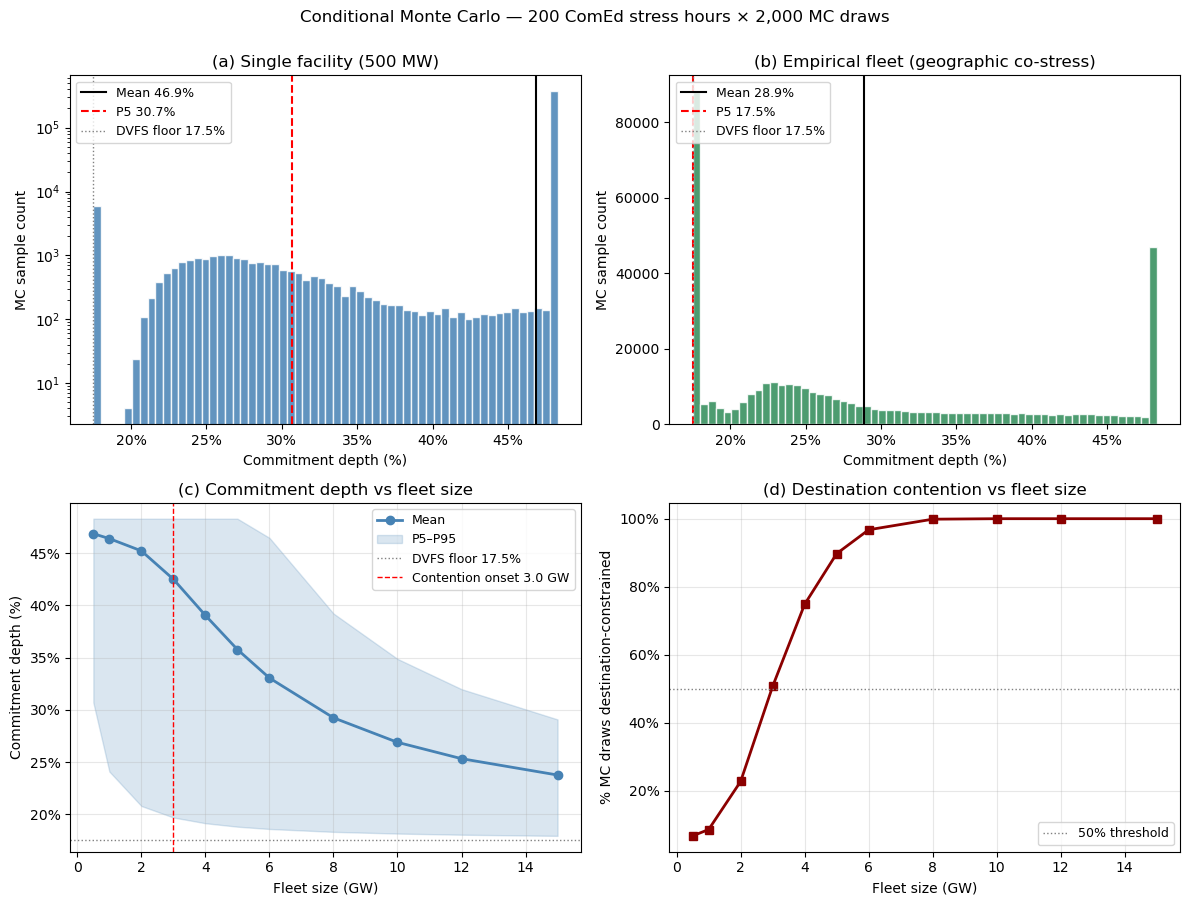

✓ Figure saved: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\figures\figure3_conditional_mc_four_panel.png


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 3-5: FOUR-PANEL CONDITIONAL MC FIGURE (Fig. 3)
# ══════════════════════════════════════════════════════════════════════════════
# Four-panel figure for paper §5:
#   (a) Single-facility commitment depth histogram (500 MW)
#   (b) Empirical fleet commitment depth histogram
#   (c) Per-GW sweep: commitment depth vs fleet size (mean + P5 + P95 band)
#   (d) Per-GW sweep: % constrained vs fleet size
#
# Saved to outputs/figures/figure3_conditional_mc_four_panel.png
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# ─── Panel (a): Single facility histogram ────────────────────────────────────
_ax = axes[0, 0]
_flat_single = single_fac_commit_depths.flatten()
_ax.hist(_flat_single * 100, bins=60, color='steelblue',
         edgecolor='white', alpha=0.85)
_ax.axvline(SINGLE_FAC_RESULTS['mean_commit_depth'] * 100,
            color='black', linewidth=1.5, label=f"Mean {SINGLE_FAC_RESULTS['mean_commit_depth']:.1%}")
_ax.axvline(SINGLE_FAC_RESULTS['p5_commit_depth'] * 100,
            color='red', linewidth=1.5, linestyle='--',
            label=f"P5 {SINGLE_FAC_RESULTS['p5_commit_depth']:.1%}")
_ax.axvline(FLEX_ONLY_FLOOR * 100,
            color='gray', linewidth=1, linestyle=':',
            label=f"Flex floor {FLEX_ONLY_FLOOR:.1%}")
_ax.set_xlabel("Commitment depth (%)")
_ax.set_ylabel("MC sample count")
_ax.set_title(f"(a) Single facility ({SINGLE_FAC_MW} MW)")
_ax.legend(loc='upper left', fontsize=9)
_ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
_ax.set_yscale('log')


# ─── Panel (b): Empirical fleet histogram ────────────────────────────────────
_ax = axes[0, 1]
_flat_fleet = fleet_commit_depths.flatten()
_ax.hist(_flat_fleet * 100, bins=60, color='seagreen',
         edgecolor='white', alpha=0.85)
_ax.axvline(EMPIRICAL_FLEET_RESULTS['mean_commit_depth'] * 100,
            color='black', linewidth=1.5,
            label=f"Mean {EMPIRICAL_FLEET_RESULTS['mean_commit_depth']:.1%}")
_ax.axvline(EMPIRICAL_FLEET_RESULTS['p5_commit_depth'] * 100,
            color='red', linewidth=1.5, linestyle='--',
            label=f"P5 {EMPIRICAL_FLEET_RESULTS['p5_commit_depth']:.1%}")
_ax.axvline(FLEX_ONLY_FLOOR* 100,
            color='gray', linewidth=1, linestyle=':',
            label=f"FLEX floor {FLEX_ONLY_FLOOR:.1%}")
_ax.set_xlabel("Commitment depth (%)")
_ax.set_ylabel("MC sample count")
_ax.set_title("(b) Empirical fleet (geographic co-stress)")
_ax.legend(loc='upper left', fontsize=9)
_ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# ─── Panel (c): Per-GW sweep — depth vs fleet size ───────────────────────────
_ax = axes[1, 0]
_ax.plot(sweep_df['fleet_gw'], sweep_df['mean'] * 100,
         color='steelblue', linewidth=2, marker='o', label='Mean')
_ax.fill_between(sweep_df['fleet_gw'],
                 sweep_df['p5'] * 100, sweep_df['p95'] * 100,
                 alpha=0.2, color='steelblue', label='P5–P95')
_ax.axhline(FLEX_ONLY_FLOOR * 100,
            color='gray', linewidth=1, linestyle=':',
            label=f"FLEX floor {FLEX_ONLY_FLOOR:.1%}")
if contention_onset_gw is not None:
    _ax.axvline(contention_onset_gw, color='red', linewidth=1, linestyle='--',
                label=f"Contention onset {contention_onset_gw:.1f} GW")
_ax.set_xlabel("Fleet size (GW)")
_ax.set_ylabel("Commitment depth (%)")
_ax.set_title("(c) Commitment depth vs fleet size")
_ax.legend(loc='upper right', fontsize=9)
_ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
_ax.grid(True, alpha=0.3)

# ─── Panel (d): Per-GW sweep — % constrained vs fleet size ───────────────────
_ax = axes[1, 1]
_ax.plot(sweep_df['fleet_gw'], sweep_df['pct_constrained'],
         color='darkred', linewidth=2, marker='s')
_ax.axhline(50, color='gray', linewidth=1, linestyle=':', label='50% threshold')
_ax.set_xlabel("Fleet size (GW)")
_ax.set_ylabel("% MC draws destination-constrained")
_ax.set_title("(d) Destination contention vs fleet size")
_ax.legend(loc='lower right', fontsize=9)
_ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
_ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Conditional Monte Carlo — {n_stress_hours} ComEd stress hours × "
    f"{N_DRAWS:,} MC draws",
    fontsize=12, y=1.00
)
plt.tight_layout()

_figpath = FIGURES_DIR / "figure3_conditional_mc_four_panel.png"
plt.savefig(_figpath, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved: {_figpath}")

## Part 4: Sensitivity Analysis (§5, Methods)

- **4-1** 2D sensitivity surface — D2 × D5 at 10 GW (Figure 6a)
- **4-2** Tornado chart — one-at-a-time at 10 GW (Figure 6b)

Evaluates how fleet commitment depth varies across the plausible ranges of
the dominant uncertainty parameters. D2 (utilization headroom) and D5
(pre-staging readiness) span the widest uncertainty and together with D4
account for the full sensitivity range. Source-side parameters show near-zero
sensitivity at fleet scale because the fleet is entirely destination-constrained.

### 4.1 2D Sensitivity Surface — D2 × D5 at 10 GW

Sweeps utilization headroom (D2) and pre-staging readiness (D5) across their full ranges on an 11 × 11 grid, with D3 and D4 held at central values. Commitment depth is computed deterministically per stress hour (no MC draws) at 10 GW fleet scale. Produces Figure 6a and `outputs/tables/sensitivity_surface.csv`.

✓ Figure saved: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\figures\figure6a_sensitivity_surface.png


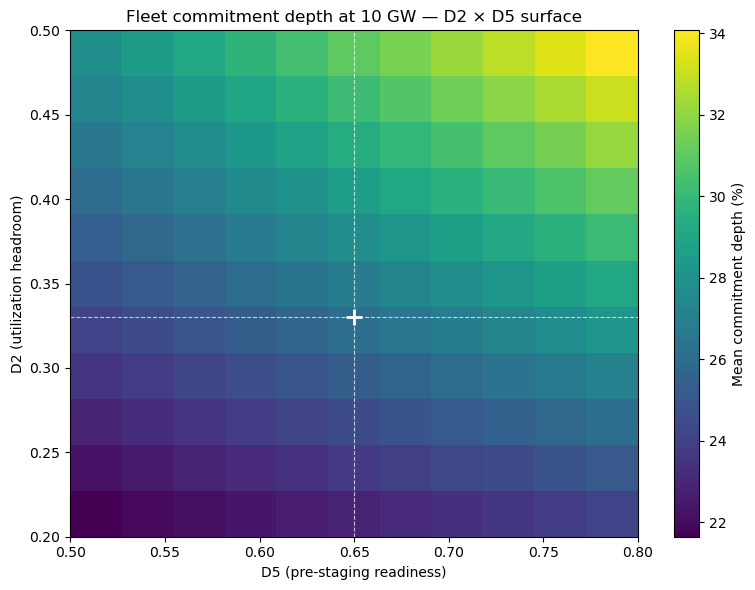


2D SENSITIVITY SURFACE SUMMARY (10 GW fleet)
  D2 range: [0.20, 0.50]
  D5 range: [0.50, 0.80]
  D3 = 0.88 (fixed), D4 = 0.50 (central)
  Mean depth range: [21.6%, 34.1%]
  Central (D2=0.33, D5=0.65): 26.1%
  Wrote sensitivity_surface.csv


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 4-1: 2D SENSITIVITY SURFACE — D2 × D5 AT 10 GW (Figure 6a)
# ══════════════════════════════════════════════════════════════════════════════
# Deterministic sweep: for each (D2, D5) pair, compute hour-by-hour commitment
# depth at 10 GW fleet scale with D3 and D4 held at central values. D1 is
# observed per-hour from the parquet (the "conditional" layer). No MC draws —
# this is a pure parameter surface.
#
# INPUTS:  hour_dest_available_mw, CASCADE_RANGES, S1/S2/S3/D3/E1/E2 fixed,
#          FLEX_FRAC
# OUTPUTS: sensitivity_surface (DataFrame), figure saved to outputs/figures/
# ══════════════════════════════════════════════════════════════════════════════

SENS_FLEET_MW = 10_000  # 10 GW reference case

_D2_lo, _D2_central, _D2_hi = CASCADE_RANGES['D2']
_D4_lo, _D4_central, _D4_hi = CASCADE_RANGES['D4']
_D5_lo, _D5_central, _D5_hi = CASCADE_RANGES['D5']

N_GRID = 11  # 11 × 11 grid
_d2_grid = np.linspace(_D2_lo, _D2_hi, N_GRID)
_d5_grid = np.linspace(_D5_lo, _D5_hi, N_GRID)

_fleet_wants = SENS_FLEET_MW * SOURCE_SIDE_FRAC

surface_results = []
for _d2 in _d2_grid:
    for _d5 in _d5_grid:
        # Deterministic: D3 and D4 at central, sweep D2 and D5
        _dest_multiplier = _d2 * D3_FIXED * _D4_central * _d5

        _hour_depths = []
        for _h in range(n_stress_hours):
            _avail = hour_dest_available_mw[_h]
            _raw_headroom = sum(_avail.values())
            _effective_headroom = _raw_headroom * _dest_multiplier
            _feasible = min(_fleet_wants, _effective_headroom) * E1_FIXED * E2_FIXED
            _spatial_frac = _feasible / SENS_FLEET_MW
            _commit = _spatial_frac + FLEX_FRAC * (S1_FIXED - _spatial_frac)
            _hour_depths.append(_commit)

        surface_results.append({
            'd2': _d2,
            'd5': _d5,
            'mean_depth': np.mean(_hour_depths),
            'p5_depth': np.percentile(_hour_depths, 5),
            'pct_constrained': 100 * np.mean(
                [1 if sum(hour_dest_available_mw[h].values()) * _dest_multiplier < _fleet_wants
                 else 0 for h in range(n_stress_hours)]
            ),
        })

sensitivity_surface = pd.DataFrame(surface_results)

# ─── Figure ──────────────────────────────────────────────────────────────────
_pivot = sensitivity_surface.pivot(index='d2', columns='d5', values='mean_depth')

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
_im = ax.imshow(
    _pivot.values * 100,
    origin='lower',
    aspect='auto',
    extent=[_d5_grid[0], _d5_grid[-1], _d2_grid[0], _d2_grid[-1]],
    cmap='viridis',
)
_cb = fig.colorbar(_im, ax=ax, label='Mean commitment depth (%)')

# Mark central values
ax.axhline(_D2_central, color='white', ls='--', lw=0.8, alpha=0.7)
ax.axvline(_D5_central, color='white', ls='--', lw=0.8, alpha=0.7)
ax.plot(_D5_central, _D2_central, 'w+', ms=12, mew=2)

ax.set_xlabel('D5 (pre-staging readiness)')
ax.set_ylabel('D2 (utilization headroom)')
ax.set_title(f'Fleet commitment depth at {SENS_FLEET_MW/1000:.0f} GW — D2 × D5 surface')

fig.tight_layout()
_fig_path = REPO_ROOT / 'outputs' / 'figures' / 'figure6a_sensitivity_surface.png'
fig.savefig(_fig_path, dpi=150, bbox_inches='tight')
print(f"✓ Figure saved: {_fig_path}")
plt.show()

# ─── Summary ─────────────────────────────────────────────────────────────────
_min_depth = sensitivity_surface['mean_depth'].min()
_max_depth = sensitivity_surface['mean_depth'].max()
_nearest_idx = (
    (sensitivity_surface['d2'] - _D2_central).abs() +
    (sensitivity_surface['d5'] - _D5_central).abs()
).idxmin()
_central_depth = sensitivity_surface.loc[_nearest_idx, 'mean_depth']

print(f"\n2D SENSITIVITY SURFACE SUMMARY ({SENS_FLEET_MW/1000:.0f} GW fleet)")
print("=" * 60)
print(f"  D2 range: [{_D2_lo:.2f}, {_D2_hi:.2f}]")
print(f"  D5 range: [{_D5_lo:.2f}, {_D5_hi:.2f}]")
print(f"  D3 = {D3_FIXED:.2f} (fixed), D4 = {_D4_central:.2f} (central)")
print(f"  Mean depth range: [{_min_depth:.1%}, {_max_depth:.1%}]")
print(f"  Central (D2={_D2_central}, D5={_D5_central}): {_central_depth:.1%}")

# ─── Export CSV ──────────────────────────────────────────────────────────────
_csv_path = REPO_ROOT / 'outputs' / 'tables' / 'sensitivity_surface.csv'
sensitivity_surface.to_csv(_csv_path, index=False)
print(f"  Wrote {_csv_path.name}")

### 4.2 Tornado Chart — One-at-a-Time at 10 GW

Sweeps each of the nine stochastic parameters (S1 is fixed) from its lower to upper bound while holding all others at central values. Identifies which parameters drive fleet-scale commitment depth variation and which are absorbed by destination contention. Produces Figure 6b and `outputs/tables/sensitivity_tornado.csv`.

✓ Figure saved: C:\Users\dunla\repos\data-center-flexibility-resource-adequacy\outputs\figures\figure6b_sensitivity_tornado.png


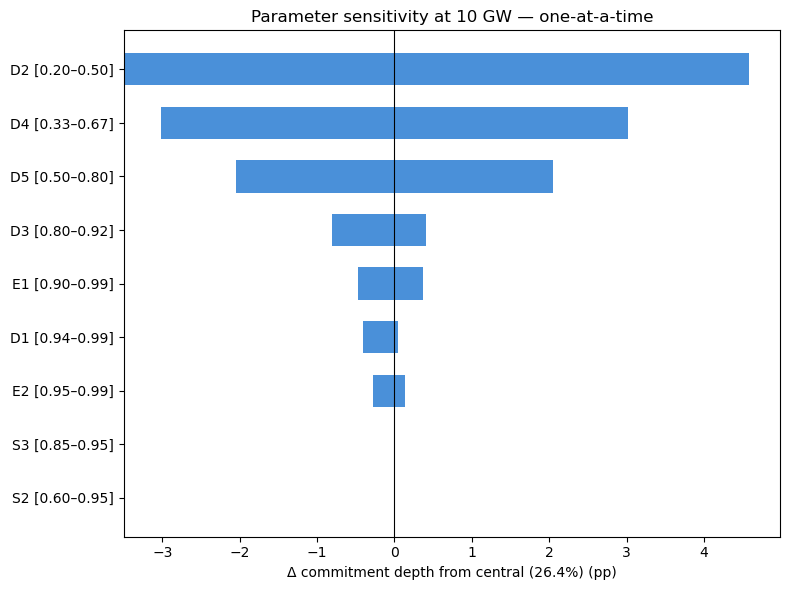


TORNADO SENSITIVITY (10 GW fleet)
  Baseline (all central): 26.4%

  Param  |    Lo |    Hi |  Depth@Lo |  Depth@Hi |   Range
  ────────────────────────────────────────────────────────────
  D2     |  0.20 |  0.50 |    22.9% |    31.0% |    8.1pp
  D4     |  0.33 |  0.67 |    23.4% |    29.4% |    6.0pp
  D5     |  0.50 |  0.80 |    24.3% |    28.4% |    4.1pp
  D3     |  0.80 |  0.92 |    25.6% |    26.8% |    1.2pp
  E1     |  0.90 |  0.99 |    25.9% |    26.8% |    0.8pp
  D1     |  0.94 |  0.99 |    26.0% |    26.4% |    0.4pp
  E2     |  0.95 |  0.99 |    26.1% |    26.5% |    0.4pp
  S3     |  0.85 |  0.95 |    26.4% |    26.4% |    0.0pp
  S2     |  0.60 |  0.95 |    26.4% |    26.4% |    0.0pp

  Wrote sensitivity_tornado.csv


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 4-2: TORNADO CHART — ONE-AT-A-TIME AT 10 GW (Figure 6b)
# ══════════════════════════════════════════════════════════════════════════════
# Sweeps each of the 10 cascade parameters from its lower to upper bound while
# holding all others at central values. Deterministic per-hour computation at
# 10 GW fleet scale (same framework as Cell 4-1).
#
# INPUTS:  hour_dest_available_mw, CASCADE_RANGES, fixed params, FLEX_FRAC
# OUTPUTS: tornado_df (DataFrame), figure saved, CSV exported
# ══════════════════════════════════════════════════════════════════════════════

TORNADO_FLEET_MW = 10_000  # 10 GW

# Central values for all parameters (used as baseline, each swept in turn)
_central = {
    'S2': CASCADE_S2, 'S3': CASCADE_S3,
    'D1': CASCADE_D1, 'D2': CASCADE_D2, 'D3': CASCADE_D3,
    'D4': CASCADE_D4, 'D5': CASCADE_D5,
    'E1': CASCADE_E1, 'E2': CASCADE_E2,
}

# S1 is fixed (scenario-defining), not swept
_swept_params = ['S2', 'S3', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2']

def _compute_fleet_depth_deterministic(params, fleet_mw):
    """Compute mean commitment depth across stress hours at given parameter values."""
    _source_frac = S1_FIXED * params['S2'] * params['S3']
    _fleet_wants = fleet_mw * _source_frac
    _dest_mult = params['D2'] * params['D3'] * params['D4'] * params['D5']

    _depths = []
    for _h in range(n_stress_hours):
        _avail = hour_dest_available_mw[_h]
        _raw_headroom = sum(_avail.values())
        # D1 is observed per-hour; when sweeping D1 parametrically, scale headroom
        # For non-D1 sweeps, D1 effect is already baked into the parquet (binary)
        if 'D1' in params and params['D1'] != CASCADE_D1:
            # Parametric D1: scale headroom by D1/D1_central ratio
            _raw_headroom *= params['D1'] / CASCADE_D1
        _effective = _raw_headroom * _dest_mult
        _feasible = min(_fleet_wants, _effective) * params['E1'] * params['E2']
        _spatial = _feasible / fleet_mw
        _commit = _spatial + FLEX_FRAC * (S1_FIXED - _spatial)
        _depths.append(_commit)
    return np.mean(_depths)

# Baseline at all-central
_baseline_depth = _compute_fleet_depth_deterministic(_central, TORNADO_FLEET_MW)

tornado_results = []
for _param in _swept_params:
    _lo, _cen, _hi = CASCADE_RANGES[_param]

    # Low sweep
    _params_lo = dict(_central)
    _params_lo[_param] = _lo
    _depth_lo = _compute_fleet_depth_deterministic(_params_lo, TORNADO_FLEET_MW)

    # High sweep
    _params_hi = dict(_central)
    _params_hi[_param] = _hi
    _depth_hi = _compute_fleet_depth_deterministic(_params_hi, TORNADO_FLEET_MW)

    tornado_results.append({
        'param': _param,
        'lo_val': _lo,
        'hi_val': _hi,
        'depth_at_lo': _depth_lo,
        'depth_at_hi': _depth_hi,
        'range_pp': abs(_depth_hi - _depth_lo) * 100,
    })

tornado_df = pd.DataFrame(tornado_results).sort_values('range_pp', ascending=True)

# ─── Figure ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

_y_pos = range(len(tornado_df))
_lo_deltas = (tornado_df['depth_at_lo'].values - _baseline_depth) * 100
_hi_deltas = (tornado_df['depth_at_hi'].values - _baseline_depth) * 100

ax.barh(_y_pos, _hi_deltas - _lo_deltas, left=_lo_deltas,
        color='#4a90d9', edgecolor='none', height=0.6)

ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(list(_y_pos))
ax.set_yticklabels([f"{r['param']} [{r['lo_val']:.2f}–{r['hi_val']:.2f}]"
                     for _, r in tornado_df.iterrows()])
ax.set_xlabel(f'Δ commitment depth from central ({_baseline_depth:.1%}) (pp)')
ax.set_title(f'Parameter sensitivity at {TORNADO_FLEET_MW/1000:.0f} GW — one-at-a-time')

fig.tight_layout()
_fig_path = REPO_ROOT / 'outputs' / 'figures' / 'figure6b_sensitivity_tornado.png'
fig.savefig(_fig_path, dpi=150, bbox_inches='tight')
print(f"✓ Figure saved: {_fig_path}")
plt.show()

# ─── Summary ─────────────────────────────────────────────────────────────────
print(f"\nTORNADO SENSITIVITY ({TORNADO_FLEET_MW/1000:.0f} GW fleet)")
print("=" * 70)
print(f"  Baseline (all central): {_baseline_depth:.1%}")
print()
print(f"  {'Param':<6} | {'Lo':>5} | {'Hi':>5} | {'Depth@Lo':>9} | {'Depth@Hi':>9} | {'Range':>7}")
print("  " + "─" * 60)
for _, _r in tornado_df.iloc[::-1].iterrows():  # descending by range
    print(f"  {_r['param']:<6} | {_r['lo_val']:>5.2f} | {_r['hi_val']:>5.2f} | "
          f"{_r['depth_at_lo']:>8.1%} | {_r['depth_at_hi']:>8.1%} | "
          f"{_r['range_pp']:>6.1f}pp")

# ─── Export CSV ──────────────────────────────────────────────────────────────
_csv_path = REPO_ROOT / 'outputs' / 'tables' / 'sensitivity_tornado.csv'
tornado_df.to_csv(_csv_path, index=False)
print(f"\n  Wrote {_csv_path.name}")

## Part 5: Contract Exports

Writes two JSON contracts consumed by notebook 03, plus the sensitivity CSVs
already written in Part 4:

1. `outputs/contracts/cascade_parameters.json` — ten parameters, ranges, variance shares, cascade products
2. `outputs/contracts/conditional_mc_results.json` — single-facility, empirical fleet, per-GW sweep, contention onset

Running this Part overwrites these files. Do not hand-edit; regenerate by
re-running this notebook.

### 5.1 Export Cascade Parameters

Writes `outputs/contracts/cascade_parameters.json` — consumed by notebook 03 Part 0. Contains the ten-parameter definitions, ranges, grounding tags, static cascade products (conservative/central/optimistic), commitment depth baseline, and variance decomposition η² shares.

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 5-1: EXPORT cascade_parameters.json
# ══════════════════════════════════════════════════════════════════════════════
# Contract consumed by notebook 03 Part 0.
# Contains the ten-parameter cascade definition, variance decomposition, and
# static cascade products. Notebook 03 uses this for ELCC and avoided cost.
# ══════════════════════════════════════════════════════════════════════════════

_grounding = {
    'S1': 'STRUCTURAL', 'S2': 'ESTIMATED-WEAK', 'S3': 'DATA',
    'D1': 'DATA', 'D2': 'ESTIMATED-WEAK', 'D3': 'ESTIMATED-MODERATE',
    'D4': 'ESTIMATED-MODERATE', 'D5': 'ESTIMATED-WEAK',
    'E1': 'ESTIMATED', 'E2': 'DATA',
}

_param_names = ['S1', 'S2', 'S3', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2']
_cascade_vars = {
    'S1': CASCADE_S1, 'S2': CASCADE_S2, 'S3': CASCADE_S3,
    'D1': CASCADE_D1, 'D2': CASCADE_D2, 'D3': CASCADE_D3,
    'D4': CASCADE_D4, 'D5': CASCADE_D5,
    'E1': CASCADE_E1, 'E2': CASCADE_E2,
}

cascade_contract = {
    "version": "1.0",
    "produced_by": "notebook 02 — cascade_simulation",
    "parameters": {
        p: {
            "central": float(_cascade_vars[p]),
            "range": [float(CASCADE_RANGES[p][0]),
                      float(CASCADE_RANGES[p][1]),
                      float(CASCADE_RANGES[p][2])],
            "grounding": _grounding[p],
        }
        for p in _param_names
    },
    "cascade_product": {
        "conservative": float(CASCADE_CONSERVATIVE),
        "central": float(EFFECTIVE_SPATIAL_FRAC),
        "optimistic": float(CASCADE_OPTIMISTIC),
    },
    "commitment_depth_baseline": float(COMMITMENT_DEPTH_BASELINE),
    "flex_floor_facility": float(FLEX_ONLY_FLOOR),
    "flex_frac": float(FLEX_FRAC),
    "variance_decomposition_eta_squared": {
        k: float(v) for k, v in CASCADE_ETA_SQ.items()
    },
    "notes": "Ten-parameter cascade from NE paper Section 2. Flex applied to S1 envelope only (Colangelo et al. 2025).",
}

_path = CONTRACTS_DIR / 'cascade_parameters.json'
with open(_path, 'w') as f:
    json.dump(cascade_contract, f, indent=2)

print(f"✓ Wrote {_path.name}")
print(f"  Central cascade product:  {EFFECTIVE_SPATIAL_FRAC:.4f}")
print(f"  Commitment depth baseline: {COMMITMENT_DEPTH_BASELINE:.1%}")
print(f"  Parameters: {len(_param_names)}")
print(f"  Variance η² entries: {len(CASCADE_ETA_SQ)}")

✓ Wrote cascade_parameters.json
  Central cascade product:  0.0384
  Commitment depth baseline: 20.4%
  Parameters: 10
  Variance η² entries: 9


### 5.2 Export Conditional MC Results

Writes `outputs/contracts/conditional_mc_results.json` — consumed by notebook 03 Parts 1–2. Contains single-facility and empirical fleet results, the full per-GW sweep table, contention onset, and sensitivity summary statistics.

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 5-2: EXPORT conditional_mc_results.json
# ══════════════════════════════════════════════════════════════════════════════
# Contract consumed by notebook 03 Parts 1–2.
# Contains conditional MC results: single-facility, empirical fleet, per-GW
# sweep, and contention onset. Notebook 03 uses these for accredited MW and
# avoided capacity cost calculations.
# ══════════════════════════════════════════════════════════════════════════════

conditional_mc_contract = {
    "version": "1.0",
    "produced_by": "notebook 02 — cascade_simulation",
    "n_draws_per_hour": N_DRAWS,
    "n_stress_hours": n_stress_hours,
    "source_zone": "PJM_COMED",
    "single_facility_500mw": {
        "facility_mw": int(SINGLE_FAC_RESULTS['facility_mw']),
        "mean_commitment_depth": float(SINGLE_FAC_RESULTS['mean_commit_depth']),
        "median": float(SINGLE_FAC_RESULTS['median_commit_depth']),
        "p5": float(SINGLE_FAC_RESULTS['p5_commit_depth']),
        "p95": float(SINGLE_FAC_RESULTS['p95_commit_depth']),
        "cvar5": float(SINGLE_FAC_RESULTS['cvar5']),
        "pct_constrained": float(SINGLE_FAC_RESULTS['pct_constrained']),
    },
    "empirical_fleet": {
        "mean_commitment_depth": float(EMPIRICAL_FLEET_RESULTS['mean_commit_depth']),
        "median": float(EMPIRICAL_FLEET_RESULTS['median_commit_depth']),
        "p5": float(EMPIRICAL_FLEET_RESULTS['p5_commit_depth']),
        "cvar5": float(EMPIRICAL_FLEET_RESULTS['cvar5']),
        "pct_constrained": float(EMPIRICAL_FLEET_RESULTS['pct_constrained']),
        "mean_migrating_mw": float(EMPIRICAL_FLEET_RESULTS['mean_migrating_mw']),
        "max_migrating_mw": float(EMPIRICAL_FLEET_RESULTS['max_migrating_mw']),
    },
    "per_gw_sweep": sweep_df.to_dict(orient='records'),
    "contention_onset_gw": float(contention_onset_gw) if contention_onset_gw is not None else None,
    "sensitivity": {
        "surface_fleet_mw": SENS_FLEET_MW,
        "surface_depth_range": [
            float(sensitivity_surface['mean_depth'].min()),
            float(sensitivity_surface['mean_depth'].max()),
        ],
        "tornado_fleet_mw": TORNADO_FLEET_MW,
        "tornado_baseline_depth": float(_baseline_depth),
    },
}

_path = CONTRACTS_DIR / 'conditional_mc_results.json'
with open(_path, 'w') as f:
    json.dump(conditional_mc_contract, f, indent=2, default=str)

print(f"✓ Wrote {_path.name}")
print(f"  Single facility (500 MW):  mean={SINGLE_FAC_RESULTS['mean_commit_depth']:.1%}")
print(f"  Empirical fleet:           mean={EMPIRICAL_FLEET_RESULTS['mean_commit_depth']:.1%}")
print(f"  Per-GW sweep:              {len(sweep_df)} fleet sizes")
print(f"  Contention onset:          {contention_onset_gw} GW")
print(f"  Sensitivity surface:       [{sensitivity_surface['mean_depth'].min():.1%}, "
      f"{sensitivity_surface['mean_depth'].max():.1%}]")

✓ Wrote conditional_mc_results.json
  Single facility (500 MW):  mean=46.9%
  Empirical fleet:           mean=28.9%
  Per-GW sweep:              11 fleet sizes
  Contention onset:          3.0 GW
  Sensitivity surface:       [21.6%, 34.1%]
